# BuildSafe — NYC Construction Violation Severity Prediction
## Notebook 1: Problem Understanding, Dataset Understanding & Exploratory Data Analysis

**Module:** IT3051 – Fundamentals of Data Mining (Mini Project 2026)
**Group:** Y3S2.WE.01.02  **Dataset:** DOB ECB Violations (NYC Open Data, NYC Department of Buildings)
**Source:** https://data.cityofnewyork.us/Housing-Development/DOB-ECB-Violations/6bgk-3dad  (extract downloaded 29-Sep-2026)

Workflow followed in this project:
**Problem Understanding → Dataset Understanding → EDA → Preprocessing → Feature Engineering → Feature Selection → Model Training**

This notebook covers the first three stages. Every section ends with a **Decision** box that feeds directly into Notebook 2 (Preprocessing).

# PART 1 — Problem Understanding

| Question | Answer |
|---|---|
| **Real-world problem** | NYC DOB inspectors issue tens of thousands of ECB (Environmental Control Board) violations every year. Each must be classified as *Immediately Hazardous*, *Major* or *Lesser*. The class drives how fast the city must follow up and how much risk the public faces. Triage today depends on an inspector picking the correct infraction code from a long legal schedule. |
| **Stakeholders / users** | DOB inspectors & supervisors (triage and QA), DOB enforcement/scheduling teams (prioritise re-inspections), property owners/managers & contractors (understand risk of an observed condition), insurers and safety consultants. |
| **Decision supported** | *"How urgently should this observed condition be treated?"* — prioritise Class 1 cases for immediate follow-up, flag inconsistent codings for review, and give owners an early risk warning before a formal code is assigned. |
| **Prediction objective** | Given the information available **at the moment a violation is observed** (what the inspector wrote, where, which unit, who is responsible, the building's history), predict the severity class. |
| **Target variable** | `SEVERITY` → `CLASS - 1` (Immediately Hazardous), `CLASS - 2` (Major), `CLASS - 3` (Lesser), defined by 1 RCNY §102-01. |
| **ML task** | **Supervised multi-class classification.** |

**Why classification?** The target is a label from a fixed set of three categories — not a continuous quantity (so not regression) and it is already known for every record (so not unsupervised clustering). The classes are ordinal in meaning, but the costs of errors are asymmetric (missing a Class 1 is worse than over-flagging a Class 3), so we treat it as nominal multi-class and monitor per-class recall rather than using an ordinal regression.

**Key constraint that shapes the whole project:** the fields that *legally define* severity (infraction code) and fields created *after* the hearing (penalty, payment, hearing outcome) must not be inputs — otherwise the model just memorises the lookup table and is useless for triage. This is investigated rigorously in Section 11.

## 0. Setup — libraries

In [38]:
import warnings, re
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
from collections import Counter

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 80)

# One consistent colour per class, used in every chart (colour follows the entity)
CLASS_ORDER  = ['CLASS - 1', 'CLASS - 2', 'CLASS - 3']
CLASS_COLORS = {'CLASS - 1': '#2a78d6', 'CLASS - 2': '#eb6834', 'CLASS - 3': '#1baf7a'}
NEUTRAL = '#2a78d6'
sns.set_theme(style='whitegrid', rc={'axes.edgecolor': '#cccccc', 'grid.color': '#eeeeee',
                                     'axes.titleweight': 'bold', 'figure.dpi': 100})

DATA_PATH = '../data/raw/DOB_ECB_Violations_20260913 (1).csv'   # <- change if your file lives elsewhere

# PART 2 — Dataset Understanding
## 1. Dataset Structure Analysis
**Purpose:** know the size, the column types and the obvious quality problems before any analysis.
We load every column as **string** first. Reason: several numeric-looking columns are really codes with leading zeros (`BLOCK`, `LOT`, `BIN`, `INFRACTION_CODE1` like `2P8`), and money columns contain thousands separators (`"6,250"`). Letting pandas guess would silently corrupt them.

In [39]:
df_raw = pd.read_csv(DATA_PATH, dtype=str, low_memory=False)
df = df_raw.copy()
print('Shape (rows, columns):', df.shape)
print(f'Memory: {df.memory_usage(deep=True).sum()/1e6:.1f} MB')

Shape (rows, columns): (102467, 46)
Memory: 246.7 MB


In [40]:
df.head()

,ISN_DOB_BIS_EXTRACT,ECB_VIOLATION_NUMBER,ECB_VIOLATION_STATUS,DOB_VIOLATION_NUMBER,BIN,BORO,BLOCK,LOT,HEARING_DATE,HEARING_TIME,SERVED_DATE,ISSUE_DATE,SEVERITY,VIOLATION_TYPE,RESPONDENT_NAME,RESPONDENT_HOUSE_NUMBER,RESPONDENT_STREET,RESPONDENT_CITY,RESPONDENT_ZIP,VIOLATION_DESCRIPTION,PENALITY_IMPOSED,AMOUNT_PAID,BALANCE_DUE,INFRACTION_CODE1,SECTION_LAW_DESCRIPTION1,INFRACTION_CODE2,SECTION_LAW_DESCRIPTION2,INFRACTION_CODE3,SECTION_LAW_DESCRIPTION3,INFRACTION_CODE4,SECTION_LAW_DESCRIPTION4,INFRACTION_CODE5,SECTION_LAW_DESCRIPTION5,INFRACTION_CODE6,SECTION_LAW_DESCRIPTION6,INFRACTION_CODE7,SECTION_LAW_DESCRIPTION7,INFRACTION_CODE8,SECTION_LAW_DESCRIPTION8,INFRACTION_CODE9,SECTION_LAW_DESCRIPTION9,INFRACTION_CODE10,SECTION_LAW_DESCRIPTION10,AGGRAVATED_LEVEL,HEARING_STATUS,CERTIFICATION_STATUS
0,1749575,39190613X,RESOLVE,NaN,2026562,2,3813,19,20260821,930,20260601,20260601,CLASS - 2,Construction,ZAPATA NEPTALI,2124,NEWBOLD AVENUE,BRONX,10462,AS PER PREVIOUS REQUEST FOR CORRECTIVE ACTION ISSUED ON 11/28/2025 BY BADGE ...,"1,250",0,"1,250",205,ZR 22-00 ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,IN VIOLATION,CERTIFICATE ACCEPTED
1,1729620,39156049P,ACTIVE,NaN,1003388,1,279,69,20270415,830,20250805,20250805,CLASS - 2,Unknown,MARINERS TEMPLE ETC,12,OLIVER STREET,NEW YORK,10038,TEMP CONSTRUCTION EQUIP/INSTALLATION ON SITE EXPIRED PERMIT(SHED). AT TIME O...,"6,250",0,"6,250",2P8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,PENDING,NaN
2,1801198,39193627K,ACTIVE,NaN,5020516,5,795,41,20260902,930,20260624,20260624,CLASS - 1,Construction,SCHWARTZ TIBOR,1583,58 STREET,BROOKLYN,11219,UNLAWFUL ACTS. FAILURE TO COMPLY WITH COMMISSIONER'S ORDER. FOR WORK WITHOUT...,"2,530",0,"2,530",187,28-201.1 ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,DEFAULT,NO COMPLIANCE RECORDED
3,1793922,39169086R,ACTIVE,NaN,4139680,4,6381,54,20260908,830,20251203,20251203,CLASS - 2,Construction,WONG MING MING,150-15,WATERSIDE COURT,WHITESTONE,11357,WORK WITHOUT A PERMIT. NOTED: OBSERVED WORK HAS BEEN DONE TO FULLY ENCLOSE T...,"1,250",0,"1,250",201,28-105.1 ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,PENDING,NaN
4,1741922,35730749Y,ACTIVE,07222026SR07NS01,2016355,2,3277,2,20261030,830,20260819,20260722,CLASS - 1,Construction,389 EAST 194 ST HDFC,2751,GRAND CONCOURSE,BRONX,10468,FAILURE TO PROVIDE UNOBSTRUCTED EXIT PASSAGEWAY. OBSERVED THE FOLLOWING OBJE...,"2,500",0,"2,500",127,"27-369,BC 1020.2 ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,PENDING,NaN


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 102467 entries, 0 to 102466
Data columns (total 46 columns):
 #   Column                     Non-Null Count   Dtype
---  ------                     --------------   -----
 0   ISN_DOB_BIS_EXTRACT        102467 non-null  str  
 1   ECB_VIOLATION_NUMBER       102467 non-null  str  
 2   ECB_VIOLATION_STATUS       102467 non-null  str  
 3   DOB_VIOLATION_NUMBER       21654 non-null   str  
 4   BIN                        102372 non-null  str  
 5   BORO                       102467 non-null  str  
 6   BLOCK                      101980 non-null  str  
 7   LOT                        101980 non-null  str  
 8   HEARING_DATE               102467 non-null  str  
 9   HEARING_TIME               102467 non-null  str  
 10  SERVED_DATE                102467 non-null  str  
 11  ISSUE_DATE                 102467 non-null  str  
 12  SEVERITY                   102467 non-null  str  
 13  VIOLATION_TYPE             102467 non-null  str  
 14  RESPONDENT_NAME

In [42]:
# describe() on the raw strings: count / unique / top / freq is the useful view for coded data
df.describe().T

,count,unique,top,freq
ISN_DOB_BIS_EXTRACT,102467,102467,1749575,1
ECB_VIOLATION_NUMBER,102467,102467,39190613X,1
ECB_VIOLATION_STATUS,102467,2,ACTIVE,59031
DOB_VIOLATION_NUMBER,21654,19986,07152025CDOE,9
BIN,102372,38743,3121398,61
BORO,102467,5,3,35973
BLOCK,101980,9887,2461,122
LOT,101980,643,1,9841
HEARING_DATE,102467,568,20261007,815
HEARING_TIME,102467,39,830,55298


### Data dictionary and feature-type categorisation

In [43]:
dictionary = {
 'ISN_DOB_BIS_EXTRACT':   ('Internal record number in DOB BIS extract', 'Identifier'),
 'ECB_VIOLATION_NUMBER':  ('ECB summons number (unique)', 'Identifier'),
 'ECB_VIOLATION_STATUS':  ('ACTIVE / RESOLVE – current case status', 'Categorical (post-event)'),
 'DOB_VIOLATION_NUMBER':  ('Linked DOB violation no. (date + issuing-unit code)', 'Identifier / text code'),
 'BIN':                   ('Building Identification Number', 'Identifier (grouping key)'),
 'BORO':                  ('Borough 1=Manhattan 2=Bronx 3=Brooklyn 4=Queens 5=Staten Is.', 'Categorical'),
 'BLOCK':                 ('Tax block', 'Identifier (location)'),
 'LOT':                   ('Tax lot', 'Identifier (location)'),
 'HEARING_DATE':          ('Currently scheduled OATH hearing date (YYYYMMDD)', 'Date (post-event, updated)'),
 'HEARING_TIME':          ('Hearing time slot (HMM)', 'Categorical (scheduling)'),
 'SERVED_DATE':           ('Date summons served on respondent', 'Date'),
 'ISSUE_DATE':            ('Date violation issued', 'Date'),
 'SEVERITY':              ('TARGET – CLASS 1 / 2 / 3', 'Target'),
 'VIOLATION_TYPE':        ('Issuing unit / violation family', 'Categorical'),
 'RESPONDENT_NAME':       ('Owner / responsible party name', 'Text (PII)'),
 'RESPONDENT_HOUSE_NUMBER':('Respondent mailing address', 'Text (PII)'),
 'RESPONDENT_STREET':     ('Respondent mailing address', 'Text (PII)'),
 'RESPONDENT_CITY':       ('Respondent mailing address', 'Categorical (PII)'),
 'RESPONDENT_ZIP':        ('Respondent mailing ZIP', 'Categorical (PII)'),
 'VIOLATION_DESCRIPTION': ('Inspector free-text description of the condition', 'Text'),
 'PENALITY_IMPOSED':      ('Penalty imposed (USD)', 'Numerical (post-event)'),
 'AMOUNT_PAID':           ('Amount paid (USD)', 'Numerical (post-event)'),
 'BALANCE_DUE':           ('Outstanding balance (USD)', 'Numerical (post-event)'),
 'INFRACTION_CODE1':      ('Primary infraction code (legal code that defines class)', 'Categorical (LEAKAGE)'),
 'SECTION_LAW_DESCRIPTION1':('Legal section + description for code 1', 'Text (LEAKAGE)'),
 'AGGRAVATED_LEVEL':      ('Aggravated offence level (NO / 1 / 2)', 'Categorical (ordinal)'),
 'HEARING_STATUS':        ('Outcome of OATH hearing', 'Categorical (post-event)'),
 'CERTIFICATION_STATUS':  ('Certificate of correction status', 'Categorical (post-event)'),
}
for i in range(2, 11):
    dictionary[f'INFRACTION_CODE{i}'] = (f'Additional infraction code {i}', 'Categorical (LEAKAGE, sparse)')
    dictionary[f'SECTION_LAW_DESCRIPTION{i}'] = (f'Legal section for code {i}', 'Text (LEAKAGE, sparse)')

dd = pd.DataFrame([(c, *dictionary[c], df[c].nunique(), round(df[c].isna().mean()*100, 2))
                   for c in df.columns],
                  columns=['column', 'meaning', 'type', 'n_unique', 'missing_%'])
dd

,column,meaning,type,n_unique,missing_%
0,ISN_DOB_BIS_EXTRACT,Internal record number in DOB BIS extract,Identifier,102467,0.00
1,ECB_VIOLATION_NUMBER,ECB summons number (unique),Identifier,102467,0.00
2,ECB_VIOLATION_STATUS,ACTIVE / RESOLVE – current case status,Categorical (post-event),2,0.00
3,DOB_VIOLATION_NUMBER,Linked DOB violation no. (date + issuing-unit code),Identifier / text code,19986,78.87
4,BIN,Building Identification Number,Identifier (grouping key),38743,0.09
5,BORO,Borough 1=Manhattan 2=Bronx 3=Brooklyn 4=Queens 5=Staten Is.,Categorical,5,0.00
6,BLOCK,Tax block,Identifier (location),9887,0.48
7,LOT,Tax lot,Identifier (location),643,0.48
8,HEARING_DATE,Currently scheduled OATH hearing date (YYYYMMDD),"Date (post-event, updated)",568,0.00
9,HEARING_TIME,Hearing time slot (HMM),Categorical (scheduling),39,0.00


In [44]:
print(dd.groupby('type')['column'].apply(list).to_string())

type
Categorical                                                                               [BORO, VIOLATION_TYPE]
Categorical (LEAKAGE)                                                                         [INFRACTION_CODE1]
Categorical (LEAKAGE, sparse)    [INFRACTION_CODE2, INFRACTION_CODE3, INFRACTION_CODE4, INFRACTION_CODE5, INF...
Categorical (PII)                                                              [RESPONDENT_CITY, RESPONDENT_ZIP]
Categorical (ordinal)                                                                         [AGGRAVATED_LEVEL]
Categorical (post-event)                            [ECB_VIOLATION_STATUS, HEARING_STATUS, CERTIFICATION_STATUS]
Categorical (scheduling)                                                                          [HEARING_TIME]
Date                                                                                   [SERVED_DATE, ISSUE_DATE]
Date (post-event, updated)                                                                 

**Findings – structure**
* **156,749 rows × 46 columns**, one row per ECB violation, issued **Jan-2024 → Sep-2026**.
* All columns arrive as text; genuine numerics are only the three money columns (all post-event) — i.e. after leakage removal there are **almost no raw numerical predictors**. Predictive signal must come from **text, categoricals and engineered history features**.
* 18 of 46 columns (`INFRACTION_CODE4-10`, `SECTION_LAW_DESCRIPTION4-10`) are **100 % empty**; codes 2–3 are 96–99.98 % empty.
* Two unique IDs (`ISN_DOB_BIS_EXTRACT`, `ECB_VIOLATION_NUMBER`) – one per row → no predictive value.
* Complexity: high-cardinality location keys (`BIN` 55k, `BLOCK` 10k), free-text description (149k unique of 156k), PII respondent fields.

| Group | Columns | Initial view |
|---|---|---|
| Numerical | PENALITY_IMPOSED, AMOUNT_PAID, BALANCE_DUE | all post-event → leakage |
| Categorical | BORO, VIOLATION_TYPE, AGGRAVATED_LEVEL, ECB_VIOLATION_STATUS, HEARING_STATUS, CERTIFICATION_STATUS, HEARING_TIME, RESPONDENT_CITY/ZIP, INFRACTION_CODE1-10 | first three are usable |
| Text | VIOLATION_DESCRIPTION, RESPONDENT_NAME, SECTION_LAW_DESCRIPTION1-10 | description = main signal |
| Date | ISSUE_DATE, SERVED_DATE, HEARING_DATE | issue date usable |
| Identifier | ISN_DOB_BIS_EXTRACT, ECB_VIOLATION_NUMBER, DOB_VIOLATION_NUMBER, BIN, BLOCK, LOT | drop raw; BIN used for history features |
| Potential leakage | INFRACTION_CODE*, SECTION_LAW_DESCRIPTION*, PENALITY_IMPOSED, AMOUNT_PAID, BALANCE_DUE, HEARING_STATUS, CERTIFICATION_STATUS, ECB_VIOLATION_STATUS, HEARING_DATE | verified in Section 11 |

# PART 3 — Exploratory Data Analysis
## 2. Target Variable Analysis
**Purpose:** confirm the target is complete, see the class balance and decide how to handle imbalance and which metric to use.

Missing target values: 0
Distinct values: <StringArray>
['CLASS - 2', 'CLASS - 1', 'CLASS - 3']
Length: 3, dtype: str
           count  percent
SEVERITY                 
CLASS - 1  40673    39.69
CLASS - 2  57607    56.22
CLASS - 3   4187     4.09

Imbalance ratio (majority / minority) = 13.8 : 1
Class 2 : Class 1 : Class 3 = 13.8 : 9.7 : 1


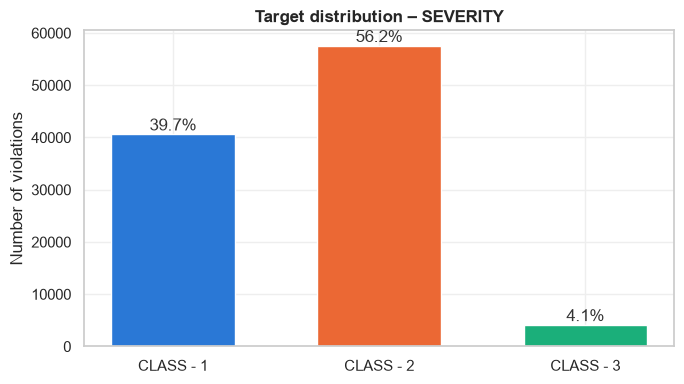

In [45]:
TARGET = 'SEVERITY'
print('Missing target values:', df[TARGET].isna().sum())
print('Distinct values:', df[TARGET].unique())
counts = df[TARGET].value_counts().reindex(CLASS_ORDER)
pct = (counts / counts.sum() * 100).round(2)
target_tbl = pd.DataFrame({'count': counts, 'percent': pct})
print(target_tbl)
print(f"\nImbalance ratio (majority / minority) = {counts.max()/counts.min():.1f} : 1")
print(f"Class 2 : Class 1 : Class 3 = {counts['CLASS - 2']/counts['CLASS - 3']:.1f} : {counts['CLASS - 1']/counts['CLASS - 3']:.1f} : 1")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, color=[CLASS_COLORS[c] for c in counts.index], width=0.6)
for b, p in zip(bars, pct.values):
    ax.text(b.get_x()+b.get_width()/2, b.get_height(), f'{p:.1f}%', ha='center', va='bottom', color='#333')
ax.set_title('Target distribution – SEVERITY'); ax.set_ylabel('Number of violations')
plt.tight_layout(); plt.show()

**Findings – target**
* **No missing target and no "Unknown" class** in this extract (the proposal anticipated one – no handling needed; we still add a guard in preprocessing).
* Class 2 ≈ 56 %, Class 1 ≈ 39 %, **Class 3 ≈ 4.2 %** → imbalance ratio ≈ **13 : 1** (moderate, not extreme).
* **Impact:** a model predicting only Class 2 gets ~56 % accuracy while never finding a Lesser violation → **accuracy is misleading**. We will use **macro-F1** (primary), per-class recall (esp. Class 1 recall – safety critical) and the confusion matrix.
* **Handling options:** (a) `class_weight='balanced'` – cheap, no synthetic data, works with sparse TF-IDF; (b) SMOTE/oversampling – synthetic TF-IDF vectors are not realistic documents and ~5k real Class 3 training rows already exist; (c) undersampling – throws away data.
  **Decision:** use **stratified / time-aware split + class weights**; test resampling only as an experiment during modelling, applied *inside training folds only*.

## 3. Missing Value Analysis
**Purpose:** quantify missingness per column and decide *column by column* (not one rule for all).

In [46]:
miss = pd.DataFrame({'missing_count': df.isna().sum(), 'missing_%': (df.isna().mean()*100).round(2)})
miss = miss[miss.missing_count > 0].sort_values('missing_%', ascending=False)
print(f'{len(miss)} of {df.shape[1]} columns have missing values')
miss

31 of 46 columns have missing values


,missing_count,missing_%
INFRACTION_CODE7,102467,100.00
SECTION_LAW_DESCRIPTION10,102467,100.00
INFRACTION_CODE10,102467,100.00
SECTION_LAW_DESCRIPTION9,102467,100.00
INFRACTION_CODE9,102467,100.00
SECTION_LAW_DESCRIPTION8,102467,100.00
INFRACTION_CODE8,102467,100.00
SECTION_LAW_DESCRIPTION7,102467,100.00
INFRACTION_CODE5,102467,100.00
SECTION_LAW_DESCRIPTION6,102467,100.00


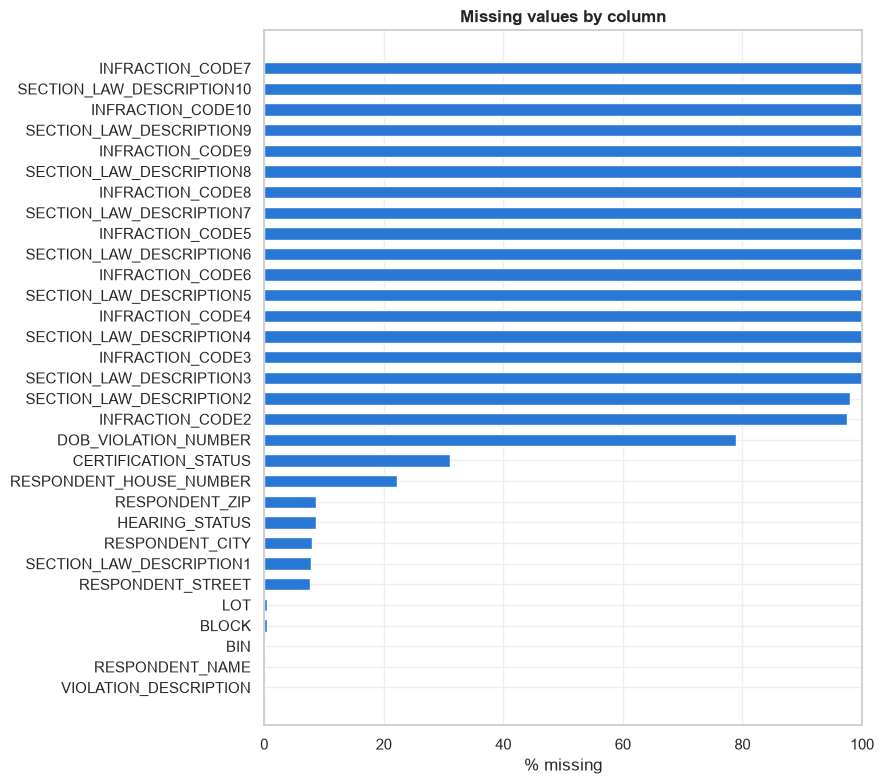

In [47]:
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(miss.index[::-1], miss['missing_%'][::-1], color=NEUTRAL, height=0.6)
ax.set_xlabel('% missing'); ax.set_title('Missing values by column'); ax.set_xlim(0, 100)
plt.tight_layout(); plt.show()

**Is missingness informative?** If the *fact* that a value is missing differs by class, the missingness itself is a signal and should be kept as a flag instead of being imputed away.

In [48]:
for col in ['DOB_VIOLATION_NUMBER', 'RESPONDENT_HOUSE_NUMBER', 'RESPONDENT_ZIP', 'HEARING_STATUS',
            'CERTIFICATION_STATUS', 'SECTION_LAW_DESCRIPTION1', 'INFRACTION_CODE2']:
    t = pd.crosstab(df[col].isna().map({True: 'missing', False: 'present'}), df[TARGET], normalize='index')*100
    print(f'\n{col}  (% of each row group in each class)'); print(t.round(1))


DOB_VIOLATION_NUMBER  (% of each row group in each class)
SEVERITY              CLASS - 1  CLASS - 2  CLASS - 3
DOB_VIOLATION_NUMBER                                 
missing                    41.4       53.5        5.1
present                    33.5       66.3        0.2

RESPONDENT_HOUSE_NUMBER  (% of each row group in each class)
SEVERITY                 CLASS - 1  CLASS - 2  CLASS - 3
RESPONDENT_HOUSE_NUMBER                                 
missing                       30.5       67.4        2.1
present                       42.3       53.0        4.6

RESPONDENT_ZIP  (% of each row group in each class)
SEVERITY        CLASS - 1  CLASS - 2  CLASS - 3
RESPONDENT_ZIP                                 
missing               9.3       90.5        0.2
present              42.6       52.9        4.5

HEARING_STATUS  (% of each row group in each class)
SEVERITY        CLASS - 1  CLASS - 2  CLASS - 3
HEARING_STATUS                                 
missing              61.7       37.8     

**Findings & per-column decisions**

| Column(s) | Missing | Decision | Reason |
|---|---|---|---|
| INFRACTION_CODE4-10, SECTION_LAW_DESCRIPTION4-10 | 100 % | **Drop** | No information at all (and leakage anyway). |
| INFRACTION_CODE2-3, SECTION_LAW_DESCRIPTION1-3 | 7.6–99.98 % | **Drop** | Leakage columns (Sec. 11) – missingness irrelevant. |
| DOB_VIOLATION_NUMBER | 75.6 % | **Keep missingness as information** → `HAS_DOB_VIOLATION` flag + issuing-unit code (`NONE` when missing) | Class 3 share is **~0.2 %** when present vs **~5.5 %** when missing → missing-not-at-random; imputing would destroy the signal. |
| CERTIFICATION_STATUS, HEARING_STATUS | 23.5 %, 6.3 % | **Drop** | Post-hearing outcomes (leakage); no imputation needed. |
| RESPONDENT_HOUSE_NUMBER / STREET / CITY / ZIP | 7–21 % | **Drop** | Mailing address of the respondent (not the building), PII, not needed. |
| RESPONDENT_NAME | 0.07 % | **Replace with "UNKNOWN"** before deriving respondent type; raw name dropped (PII) | Tiny share; category is safe. |
| BLOCK, LOT | 0.56 % | **Drop** | Location identifiers; BORO + BIN history already capture location. |
| BIN | 0.11 % | **Keep missing as NaN** → history features = 0 / "no known history" | Cannot invent a building. |
| VIOLATION_DESCRIPTION | 0.01 % (≈20 rows) | **Replace with empty string** | Rows are otherwise valid; TF-IDF of "" is a zero vector. |
| SERVED_DATE | 7 rows | Not used as feature (see Sec. 8) | — |

No **mean/median imputation** is required: the proposal listed it, but EDA shows the only numeric columns with gaps are either leakage or engineered counts that are defined (0) by construction. Imputing is therefore *not justified* here.

## 4. Duplicate and Invalid Record Analysis
**Purpose:** identical records inflate the training set and can leak across train/test (the same row in both).

In [49]:
ID_COLS = ['ISN_DOB_BIS_EXTRACT', 'ECB_VIOLATION_NUMBER']
print('Exact duplicate rows (all columns):', df.duplicated().sum())
print('Duplicate ECB violation numbers   :', df['ECB_VIOLATION_NUMBER'].duplicated().sum())
non_id = [c for c in df.columns if c not in ID_COLS]
print('Duplicates ignoring the two IDs   :', df.duplicated(subset=non_id).sum())

key = ['BIN', 'ISSUE_DATE', 'VIOLATION_DESCRIPTION']
dup_key = df[df.duplicated(subset=key, keep=False)]
print('Rows sharing BIN + issue date + description:', len(dup_key))
conf = dup_key.groupby(key)[TARGET].nunique()
print('...of those groups, with CONFLICTING severity:', (conf > 1).sum(), 'of', len(conf))

Exact duplicate rows (all columns): 0
Duplicate ECB violation numbers   : 0
Duplicates ignoring the two IDs   : 133
Rows sharing BIN + issue date + description: 1127
...of those groups, with CONFLICTING severity: 16 of 456


In [50]:
# Same description text, different class?
g = df.groupby('VIOLATION_DESCRIPTION')[TARGET].nunique()
print('Distinct descriptions mapped to >1 class:', (g > 1).sum(), 'out of', len(g))

Distinct descriptions mapped to >1 class: 89 out of 97978


### Invalid / impossible values

In [51]:
d_issue  = pd.to_datetime(df['ISSUE_DATE'],  format='%Y%m%d', errors='coerce')
d_served = pd.to_datetime(df['SERVED_DATE'], format='%Y%m%d', errors='coerce')
d_hear   = pd.to_datetime(df['HEARING_DATE'],format='%Y%m%d', errors='coerce')
money = {c: pd.to_numeric(df[c].str.replace(',', '', regex=False), errors='coerce')
         for c in ['PENALITY_IMPOSED', 'AMOUNT_PAID', 'BALANCE_DUE']}

checks = {
 'Unparseable ISSUE_DATE':                      d_issue.isna().sum(),
 'Unparseable SERVED_DATE':                     d_served.isna().sum(),
 'SERVED before ISSUE':                         (d_served < d_issue).sum(),
 'HEARING before ISSUE':                        (d_hear < d_issue).sum(),
 'ISSUE_DATE in the future (> extract date)':   (d_issue > pd.Timestamp('2026-09-29')).sum(),
 'Negative BALANCE_DUE (overpayment/refund)':   (money['BALANCE_DUE'] < 0).sum(),
 'Placeholder BIN (x000000)':                   df['BIN'].str.fullmatch(r'[1-5]000000', na=False).sum(),
 'BIN borough digit != BORO':                   ((df['BIN'].str[0] != df['BORO']) & df['BIN'].notna()).sum(),
 'ZIP not 5 digits (respondent)':               (~df['RESPONDENT_ZIP'].str.fullmatch(r'\d{5}', na=True)).sum(),
 'BORO outside 1-5':                            (~df['BORO'].isin(list('12345'))).sum(),
}
pd.Series(checks, name='rows').to_frame()

,rows
Unparseable ISSUE_DATE,0
Unparseable SERVED_DATE,7
SERVED before ISSUE,0
HEARING before ISSUE,0
ISSUE_DATE in the future (> extract date),0
Negative BALANCE_DUE (overpayment/refund),408
Placeholder BIN (x000000),81
BIN borough digit != BORO,49
ZIP not 5 digits (respondent),2920
BORO outside 1-5,0


### Inconsistent categories

In [52]:
print(df['VIOLATION_TYPE'].value_counts(), '\n')
top_names = df['RESPONDENT_NAME'].value_counts().head(8)
print(top_names)
print('\nSpelling variants of the same body, e.g. Department of Education:')
print(df.loc[df['RESPONDENT_NAME'].str.contains(r'DEP.*EDUC', na=False), 'RESPONDENT_NAME'].value_counts().head(8))

VIOLATION_TYPE
Construction           74655
Unknown                13585
Elevators               6999
Boilers                 2275
Zoning                  1385
Local Law               1241
Quality of Life          917
Site Safety              580
Cranes and Derricks      355
Plumbing                 280
Signs                    178
Public Assembly           17
Name: count, dtype: int64 

RESPONDENT_NAME
DEPARTMENT OF EDUCATION      4264
DEPT OF EDUCATION            2869
DEPARTMENT OF EDUCATION 0     286
ON STAR MANAGEMENT LLC        235
INNOVATIVE CONSTR NYC LLC     227
L&L CONSTRUCTION DEVELOP      210
MOD CONSULTANTS LLC           197
YAFE MEOD CORP                167
Name: count, dtype: int64

Spelling variants of the same body, e.g. Department of Education:
RESPONDENT_NAME
DEPARTMENT OF EDUCATION      4264
DEPT OF EDUCATION            2869
DEPARTMENT OF EDUCATION 0     286
DEPT. OF EDUCATION             43
DEPT OF EDUCATION 0            29
NYC DEPT OF EDUCATION           8
NYC DEPT

**Findings & decisions**
* **No exact duplicates** and no repeated ECB numbers (every row is a distinct summons).
* **~209 rows are identical in every field except the IDs** → true re-entries. **Decision: remove** (keep first). They would otherwise appear in both train and test.
* ~1,740 rows (703 groups) share BIN + date + description; only 27 groups have *different* severities → these are legitimate multiple summonses from one inspection (different infraction codes). **Keep.**
* Only ~150 descriptions map to more than one class → text is highly consistent with the label (good for learnability; also a reason to check text leakage, Sec. 7).
* Dates are all valid and ordered (no hearing before issue, no served before issue). **No action.**
* **Negative BALANCE_DUE** (~1,000) are refunds/over-payments – valid accounting, and the column is dropped as leakage anyway.
* **Placeholder BINs** (`1000000`, `3000000`…) are "unknown building" codes (~95 rows). **Decision: set to NaN** so they don't form a fake "building" with a huge violation history.
* 72 BIN/BORO mismatches – small; BORO is the authoritative borough field, BIN is only used as a grouping key. **Keep.**
* `VIOLATION_TYPE = 'Unknown'` (~13 %) is a genuine category in the source system – **keep as its own level**, not missing.
* `RESPONDENT_NAME` has spelling variants (DEPT OF EDUCATION / DEPARTMENT OF EDUCATION 0…). We will not use the raw name (PII), but a **normalised respondent-type** feature (Government / Organisation / Individual) resolves these variants.

## 5. Numerical Feature Analysis
**Purpose:** summarise the only raw numerics (money) and the time gaps derived from dates. Even though the money fields will be removed, the analysis is needed to *prove* they are post-event/leaky and to understand the data.

In [53]:
num = pd.DataFrame(money)
num['SERVED_LAG_DAYS']  = (d_served - d_issue).dt.days
num['HEARING_GAP_DAYS'] = (d_hear - d_issue).dt.days
summary = num.describe(percentiles=[.25, .5, .75, .95, .99]).T
summary['skew'] = num.skew()
summary['kurtosis'] = num.kurt()
summary.round(2)

,count,mean,std,min,25%,50%,75%,95%,99%,max,skew,kurtosis
PENALITY_IMPOSED,102467.0,3493.68,5677.35,0.0,1250.0,2400.0,3125.0,12500.0,25000.0,70000.0,5.81,50.45
AMOUNT_PAID,102467.0,393.99,1337.90,0.0,0.0,0.0,0.0,2500.0,5279.0,57500.0,10.13,229.65
BALANCE_DUE,102467.0,2926.90,5787.78,-35000.0,0.0,1250.0,2530.0,12500.0,25000.0,70000.0,5.66,48.33
SERVED_LAG_DAYS,102460.0,6.69,32.63,0.0,0.0,0.0,0.0,33.0,128.0,537.0,9.46,105.53
HEARING_GAP_DAYS,102467.0,184.62,163.84,1.0,69.0,86.0,282.0,526.0,670.0,881.0,1.26,0.69


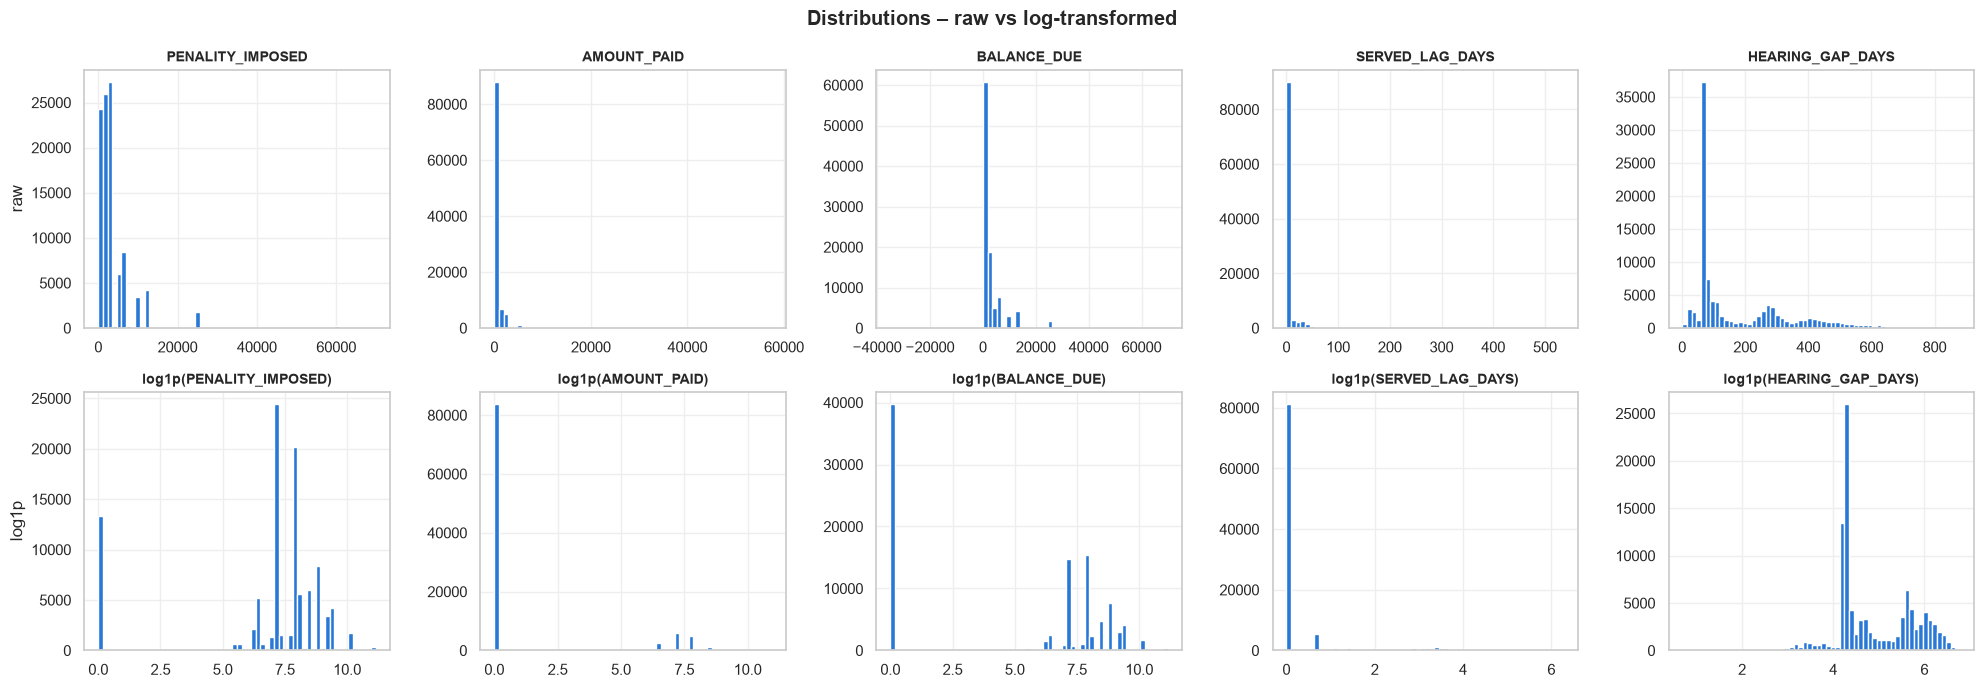

In [54]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for i, c in enumerate(num.columns):
    s = num[c].dropna()
    axes[0, i].hist(s, bins=60, color=NEUTRAL); axes[0, i].set_title(c, fontsize=10)
    axes[1, i].hist(np.log1p(s.clip(lower=0)), bins=60, color=NEUTRAL); axes[1, i].set_title(f'log1p({c})', fontsize=10)
axes[0,0].set_ylabel('raw'); axes[1,0].set_ylabel('log1p')
plt.suptitle('Distributions – raw vs log-transformed', fontweight='bold'); plt.tight_layout(); plt.show()

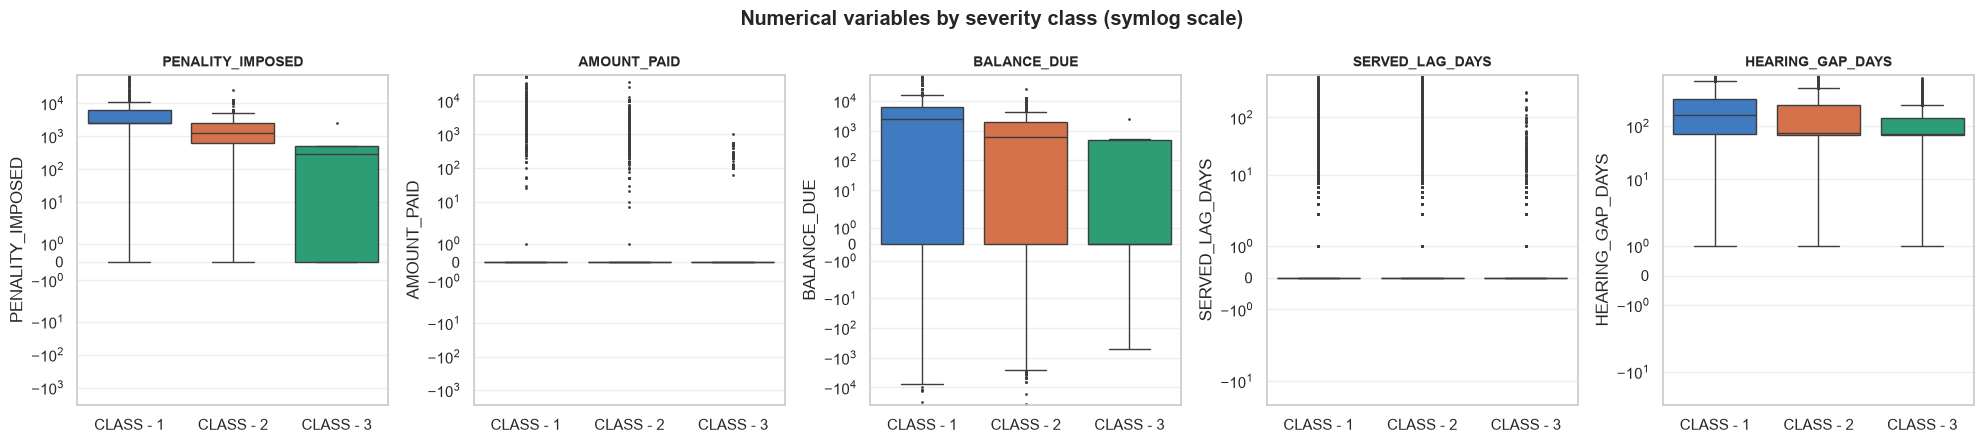

,PENALITY_IMPOSED,AMOUNT_PAID,BALANCE_DUE,SERVED_LAG_DAYS,HEARING_GAP_DAYS
SEVERITY,,,,,
CLASS - 1,2500.0,0.0,2500.0,0.0,160.0
CLASS - 2,1250.0,0.0,625.0,0.0,75.0
CLASS - 3,280.0,0.0,0.0,0.0,72.0


In [55]:
tmp = num.assign(SEVERITY=df[TARGET])
fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))
for i, c in enumerate(num.columns):
    sns.boxplot(data=tmp, x='SEVERITY', y=c, order=CLASS_ORDER, palette=CLASS_COLORS, ax=axes[i], fliersize=1)
    axes[i].set_yscale('symlog'); axes[i].set_title(c, fontsize=10); axes[i].set_xlabel('')
plt.suptitle('Numerical variables by severity class (symlog scale)', fontweight='bold'); plt.tight_layout(); plt.show()
tmp.groupby('SEVERITY')[list(num.columns)].median()

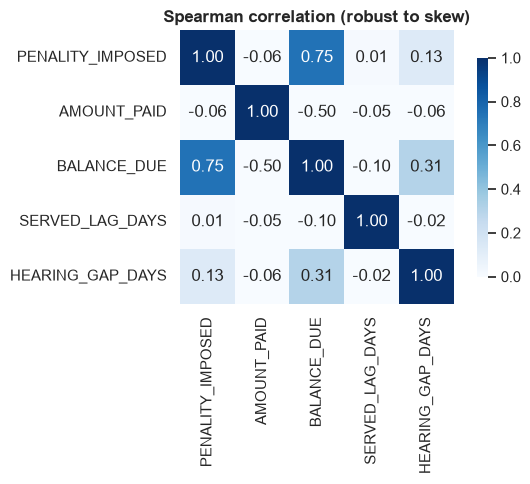

In [56]:
corr = num.corr(method='spearman')
plt.figure(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, square=True, cbar_kws={'shrink': .8})
plt.title('Spearman correlation (robust to skew)'); plt.tight_layout(); plt.show()

**Findings**
* All money columns are **heavily right-skewed** (skew > 3, huge kurtosis): median penalty $1,250 but max $70,000. SERVED_LAG is 0 days for >75 % of rows with a long tail to ~940 days.
* **PENALITY_IMPOSED medians differ sharply by class** (Class 1 ≈ $2,500, Class 2 ≈ $1,250, Class 3 ≈ $250) – because the NYC penalty schedule is *set by the class*. It is an effect of the target, not a cause → **leakage** (Sec. 11).
* PENALITY ↔ BALANCE_DUE ↔ AMOUNT_PAID are strongly correlated (they are arithmetic of one another: balance ≈ penalty − paid) → redundant as well as leaky.
* HEARING_GAP differs by class (Class 1 median ≈ 200 days vs ≈ 75 days) – but hearing dates are **re-scheduled after adjournments/defaults**, so the value in the extract reflects later case history → post-event, removed.
* SERVED_LAG has almost identical medians across classes (0) → weak signal; plus it is not always known at triage time → not used.
* **Implication:** after removing leakage, no raw numeric feature remains. Numeric inputs will be **engineered** (building history counts, text length) – and those will also be skewed counts, so we plan `log1p` for linear/NB models.

## 6. Categorical Feature Analysis
**Purpose:** cardinality, rare levels, and how strongly each category is associated with severity (Cramér's V, 0 = none, 1 = perfect).

In [57]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum(); r, k = ct.shape
    phi2 = max(0, chi2/n - (k-1)*(r-1)/(n-1))
    rc, kc = r - (r-1)**2/(n-1), k - (k-1)**2/(n-1)
    return np.sqrt(phi2 / max(1e-12, min(kc-1, rc-1)))

CAT_COLS = ['BORO', 'VIOLATION_TYPE', 'AGGRAVATED_LEVEL', 'ECB_VIOLATION_STATUS', 'HEARING_STATUS',
            'CERTIFICATION_STATUS', 'HEARING_TIME', 'RESPONDENT_CITY', 'INFRACTION_CODE1']
rows = []
for c in CAT_COLS:
    vc = df[c].fillna('MISSING').value_counts()
    rows.append({'feature': c, 'n_unique': len(vc),
                 'top_level': vc.index[0], 'top_%': round(vc.iloc[0]/len(df)*100, 1),
                 'rare_levels(<0.5%)': int((vc/len(df) < 0.005).sum()),
                 "cramers_v_vs_target": round(cramers_v(df[c].fillna('MISSING'), df[TARGET]), 3)})
cat_summary = pd.DataFrame(rows).sort_values('cramers_v_vs_target', ascending=False)
cat_summary

,feature,n_unique,top_level,top_%,rare_levels(<0.5%),cramers_v_vs_target
8,INFRACTION_CODE1,326,202,8.4,281,0.982
1,VIOLATION_TYPE,12,Construction,72.9,4,0.263
4,HEARING_STATUS,9,DEFAULT,22.5,0,0.261
7,RESPONDENT_CITY,1313,BROOKLYN,29.0,1300,0.205
5,CERTIFICATION_STATUS,6,MISSING,31.1,0,0.195
6,HEARING_TIME,39,830,54.0,32,0.139
0,BORO,5,3,35.1,0,0.094
2,AGGRAVATED_LEVEL,3,NO,91.9,0,0.068
3,ECB_VIOLATION_STATUS,2,ACTIVE,57.6,0,0.017


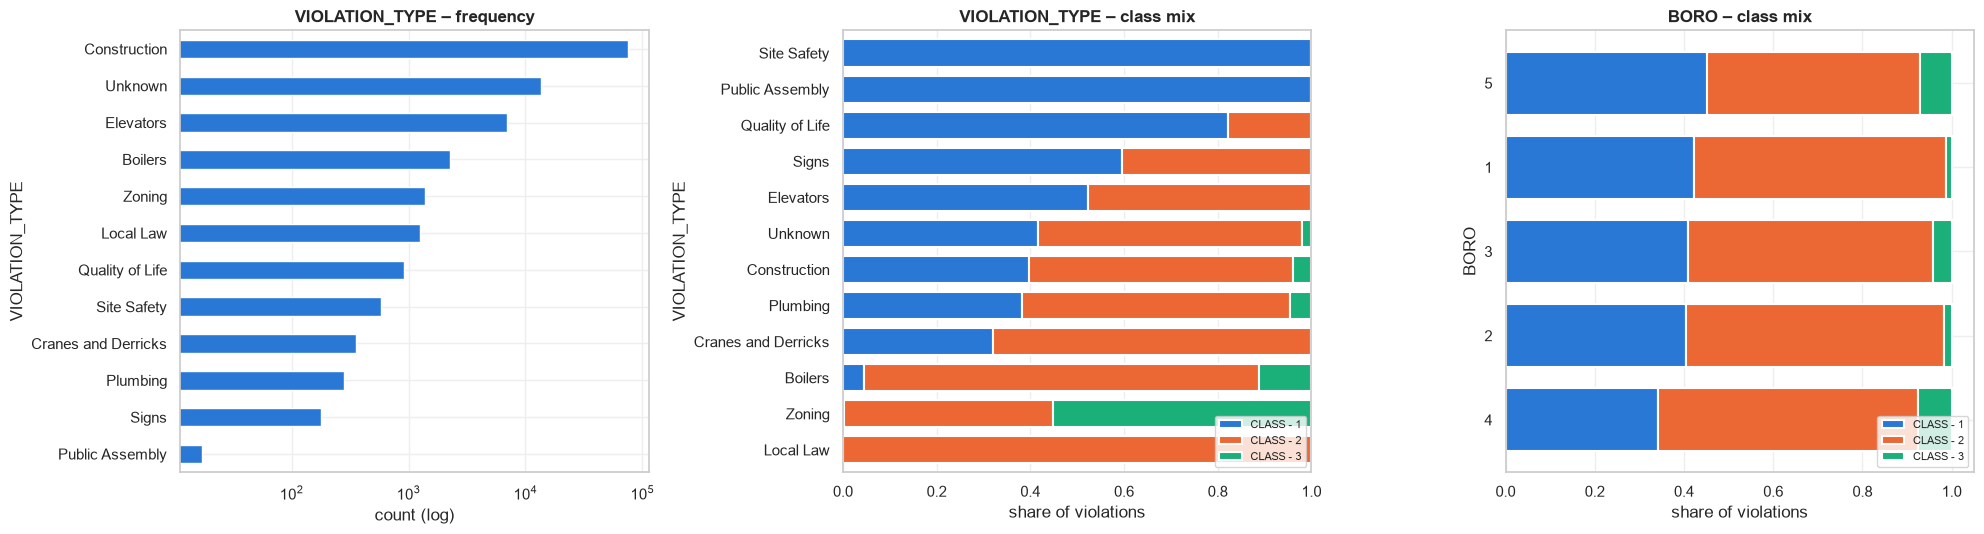

In [58]:
def class_share_plot(col, title=None, min_count=0, ax=None):
    ct = pd.crosstab(df[col].fillna('MISSING'), df[TARGET])
    ct = ct[ct.sum(1) >= min_count]
    share = ct.div(ct.sum(1), axis=0)[CLASS_ORDER].sort_values('CLASS - 1')
    share.plot(kind='barh', stacked=True, color=[CLASS_COLORS[c] for c in CLASS_ORDER],
               width=0.75, edgecolor='white', linewidth=1.5, ax=ax)
    (ax or plt.gca()).set_title(title or col); (ax or plt.gca()).set_xlabel('share of violations')
    (ax or plt.gca()).legend(loc='lower right', fontsize=8, frameon=True)
    return ct

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
df['VIOLATION_TYPE'].value_counts().sort_values().plot(kind='barh', color=NEUTRAL, ax=axes[0])
axes[0].set_title('VIOLATION_TYPE – frequency'); axes[0].set_xscale('log'); axes[0].set_xlabel('count (log)')
class_share_plot('VIOLATION_TYPE', 'VIOLATION_TYPE – class mix', ax=axes[1])
class_share_plot('BORO', 'BORO – class mix', ax=axes[2])
plt.tight_layout(); plt.show()

In [59]:
for c in ['VIOLATION_TYPE', 'BORO', 'AGGRAVATED_LEVEL']:
    ct = pd.crosstab(df[c], df[TARGET], margins=True)
    pct = (pd.crosstab(df[c], df[TARGET], normalize='index')*100).round(1).add_suffix(' %')
    display(pd.concat([ct.drop('All'), pct], axis=1))

SEVERITY,CLASS - 1,CLASS - 2,CLASS - 3,All,CLASS - 1 %,CLASS - 2 %,CLASS - 3 %
VIOLATION_TYPE,,,,,,,
Boilers,100,1920,255,2275,4.4,84.4,11.2
Construction,29573,42196,2886,74655,39.6,56.5,3.9
Cranes and Derricks,114,241,0,355,32.1,67.9,0.0
Elevators,3668,3329,2,6999,52.4,47.6,0.0
Local Law,0,1241,0,1241,0.0,100.0,0.0
Plumbing,107,160,13,280,38.2,57.1,4.6
Public Assembly,17,0,0,17,100.0,0.0,0.0
Quality of Life,754,163,0,917,82.2,17.8,0.0
Signs,106,72,0,178,59.6,40.4,0.0


SEVERITY,CLASS - 1,CLASS - 2,CLASS - 3,All,CLASS - 1 %,CLASS - 2 %,CLASS - 3 %
BORO,,,,,,,
1,8200,10960,241,19401,42.3,56.5,1.2
2,7525,10733,314,18572,40.5,57.8,1.7
3,14737,19744,1492,35973,41.0,54.9,4.1
4,8193,14029,1820,24042,34.1,58.4,7.6
5,2018,2141,320,4479,45.1,47.8,7.1


SEVERITY,CLASS - 1,CLASS - 2,CLASS - 3,All,CLASS - 1 %,CLASS - 2 %,CLASS - 3 %
AGGRAVATED_LEVEL,,,,,,,
AGGRAVATED OFFENSE LEVEL 1,3066,4206,51,7323,41.9,57.4,0.7
AGGRAVATED OFFENSE LEVEL 2,777,165,3,945,82.2,17.5,0.3
NO,36830,53236,4133,94199,39.1,56.5,4.4


**Findings**
* **VIOLATION_TYPE** (12 levels, Cramér's V ≈ 0.3) is the strongest legitimate categorical: *Site Safety* and *Public Assembly* are 100 % Class 1, *Local Law* 100 % Class 2, *Zoning* is the only type dominated by Class 3 (≈ 55 %), *Quality of Life* 84 % Class 1. **Keep → One-Hot.** Rare levels (Public Assembly = 19 rows, Plumbing, Signs, Cranes) are grouped by `min_frequency` in the encoder so that the model does not overfit a handful of rows, while keeping them distinct from "Unknown".
* **BORO** (5 levels) has a weak but real effect: Staten Island (5) and Queens (4) have 2× more Class 3 (more 1-2 family homes → zoning/lesser issues). **Keep → One-Hot.** It is nominal, so Label Encoding (1<2<3…) would impose a fake order.
* **AGGRAVATED_LEVEL** (NO / 1 / 2) is known at issuance (repeat-offender charge) and ordinal. Level 2 is 70 % Class 1. **Keep → ordinal 0/1/2.**
* **INFRACTION_CODE1** has V ≈ 0.98 → near-perfect → **leakage** (Sec. 11).
* **HEARING_STATUS / CERTIFICATION_STATUS / ECB_VIOLATION_STATUS** are outcomes that occur after issuance → **leakage/post-event**, removed regardless of association.
* **HEARING_TIME** is an OATH scheduling slot, operational not causal → drop. **RESPONDENT_CITY** is the owner's mailing city (PII, 1,686 levels) → drop.

## 7. Text Feature Analysis — `VIOLATION_DESCRIPTION`
**Purpose:** the description is what the inspector observed, available at issuance, and is the richest legitimate signal. We check length, truncation, vocabulary, duplicates and **leakage words**.

          chars     words
count  102467.0  102467.0
mean      195.5      30.5
std        30.3       5.9
min         0.0       0.0
25%       200.0      28.0
50%       210.0      32.0
75%       210.0      34.0
max       210.0      49.0

Share of descriptions at the 200-210 char cap: 75.1%
Unique descriptions: 97,979 of 102,467  (95.6%)


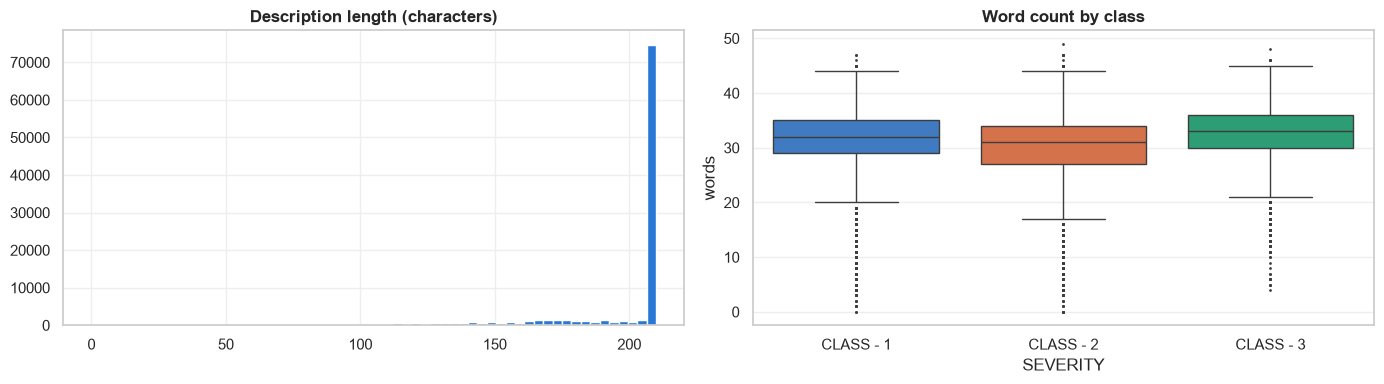

,chars,words
SEVERITY,,
CLASS - 1,210.0,32.0
CLASS - 2,210.0,31.0
CLASS - 3,210.0,33.0


In [60]:
text = df['VIOLATION_DESCRIPTION'].fillna('')
tl = pd.DataFrame({'chars': text.str.len(), 'words': text.str.split().str.len(), 'SEVERITY': df[TARGET]})
print(tl[['chars', 'words']].describe().round(1))
print(f"\nShare of descriptions at the 200-210 char cap: {(tl.chars >= 200).mean()*100:.1f}%")
print(f"Unique descriptions: {text.nunique():,} of {len(text):,}  ({text.nunique()/len(text)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(tl.chars, bins=60, color=NEUTRAL); axes[0].set_title('Description length (characters)')
sns.boxplot(data=tl, x='SEVERITY', y='words', order=CLASS_ORDER, palette=CLASS_COLORS, ax=axes[1], fliersize=1)
axes[1].set_title('Word count by class'); plt.tight_layout(); plt.show()
tl.groupby('SEVERITY')[['chars', 'words']].median()

In [61]:
STOP = set('''A AN THE OF TO AND OR IN ON AT FOR BY WITH AS IS ARE WAS WERE BE BEEN THAT THIS FROM
IT ITS NOT NO ALL ANY OTHER THERE AT TIME'''.split())
def tokens(s):
    return [w for w in re.findall(r'[A-Z]{3,}', s.upper()) if w not in STOP]

top_by_class = {}
for c in CLASS_ORDER:
    cnt = Counter(w for s in text[df[TARGET] == c] for w in tokens(s))
    top_by_class[c] = [f'{w} ({n})' for w, n in cnt.most_common(20)]
pd.DataFrame(top_by_class)

,CLASS - 1,CLASS - 2,CLASS - 3
0,OBSERVED (24177),OBSERVED (28356),OBSERVED (2442)
1,INSPECTION (15442),FAILURE (23172),FRONT (1994)
2,BUILDING (14530),INSPECTION (23060),INSPECTION (1755)
3,WORK (14513),BUILDING (18375),PERMIT (1701)
4,FAILURE (14393),FILE (15926),FENCE (1692)
5,PERMIT (12488),PERMIT (15393),HEIGHT (1558)
6,MAINTAIN (9031),CODE (14052),NOTED (1532)
7,CODE (8800),CERTIFICATE (13801),YARD (1272)
8,FLOOR (8141),MAINTAIN (12949),WITHOUT (1065)
9,WITHOUT (6550),CORRECTION (12778),FAILURE (1039)


In [62]:
# Most class-distinctive words: highest P(class | word) among frequent words
rows = []
tok_sets = text.map(lambda s: set(tokens(s)))
all_cnt = Counter(w for s in tok_sets for w in s)
freq_words = [w for w, n in all_cnt.items() if n >= 300]
exploded = pd.DataFrame({'w': tok_sets.map(list).values, 'y': df[TARGET].values}).explode('w').reset_index(drop=True)
exploded = exploded[exploded.w.isin(freq_words)]
share = pd.crosstab(exploded.w, exploded.y, normalize='index')
for c in CLASS_ORDER:
    print(f'\nMost {c}-specific words (share of docs containing the word that are {c}):')
    print(share[c].sort_values(ascending=False).head(12).round(2).to_dict())


Most CLASS - 1-specific words (share of docs containing the word that are CLASS - 1):
{'EIR': 0.97, 'CEASE': 0.97, 'ACTS': 0.96, 'RESTRICTOR': 0.95, 'UNOBSTRUCTED': 0.93, 'TRANSIENT': 0.93, 'UNLAWFULLY': 0.93, 'DEFACED': 0.93, 'CONTINUED': 0.92, 'SWO': 0.92, 'EMAIL': 0.91, 'OBEY': 0.91}

Most CLASS - 2-specific words (share of docs containing the word that are CLASS - 2):
{'DEADLINE': 1.0, 'ASSESSMENTREPORT': 1.0, 'EXAMINATION': 1.0, 'ASSESS': 1.0, 'CYCLE': 1.0, 'ACCEPTABLE': 1.0, 'DOCUMENTING': 1.0, 'RECIEVED': 0.99, 'AUDITORIUM': 0.99, 'CAFETERIA': 0.99, 'REISSUE': 0.99, 'RULES': 0.99}

Most CLASS - 3-specific words (share of docs containing the word that are CLASS - 3):
{'EXCEEDS': 0.79, 'RESOLUTION': 0.62, 'PLANTING': 0.58, 'EXCEEDING': 0.57, 'REQUIREMENT': 0.52, 'ZONING': 0.52, 'THEREOF': 0.4, 'PERMITTED': 0.4, 'CURB': 0.4, 'LEGAL': 0.37, 'DISTRICT': 0.36, 'VEHICLE': 0.36}


### Possible leakage words — does the description *state* the class?

In [63]:
patterns = {
 'CLASS 1/2/3 mentioned':      r'CLASS\s*-?\s*[123]\b',
 'IMMEDIATELY HAZARDOUS':      r'IMMEDIATELY\s+HAZARDOUS',
 'HAZARDOUS (any)':            r'HAZARDOUS',
 'MAJOR / LESSER':             r'\b(MAJOR|LESSER)\b',
 'penalty / $ amount':         r'\$\s?\d|PENALTY',
 'legal section e.g. 28-105':  r'\b28-\d{3}',
 'permit / job numbers':       r'\b[A-Z]?\d{8,}\b|[A-Z]\d{8}-',
 'dates in text':              r'\b\d{1,2}/\d{1,2}/\d{2,4}\b',
}
rows = []
for name, p in patterns.items():
    m = text.str.contains(p, regex=True)
    sh = pd.crosstab(m, df[TARGET], normalize='index').reindex(columns=CLASS_ORDER).fillna(0)
    rows.append({'pattern': name, 'rows_%': round(m.mean()*100, 2),
                 **({k: round(v*100, 1) for k, v in sh.loc[True].items()} if m.any() else {})})
pd.DataFrame(rows)

,pattern,rows_%,CLASS - 1,CLASS - 2,CLASS - 3
0,CLASS 1/2/3 mentioned,4.11,49.6,50.3,0.0
1,IMMEDIATELY HAZARDOUS,0.02,72.2,27.8,0.0
2,HAZARDOUS (any),2.56,57.2,42.4,0.4
3,MAJOR / LESSER,0.18,67.8,31.7,0.6
4,penalty / $ amount,0.05,37.0,59.3,3.7
5,legal section e.g. 28-105,2.90,24.9,74.2,0.9
6,permit / job numbers,5.19,24.0,74.7,1.3
7,dates in text,11.72,29.9,65.6,4.5


In [64]:
print(text[text.str.contains(r'CLASS\s*-?\s*[123]\b')].sample(6, random_state=1).to_string())

74968    CEASE USE ITEM: INOPERATIVE ZONE LOCK RESTRICTOR. CLASS 2 ITEMS: MISALINGED ...
23556    NO CERTIFICATE OF CORRECTION ON FILE AS PER REQUEST OF COMMISSIONER FOR CLAS...
52286    CLASS 2 ITEMS: CATEGORY 5 TEST TAG NOT PROPERLY FILLED OUT, PREVENTING VERIF...
66118    CLASS 1 ITEM: NO DOOR LOCK MONITORING INSTALLED ON THIS CONTROLLER AS MANDAT...
32038    CLASS 1: UPON INSPECTION ELEVATOR IS OUT OF SERVICE, RESTORE TO SERVICE AS P...
54990    CLASS 2 ITEMS: ACCESS TO ELEVATOR MACHINE ROOM WAS NOT PROVIDED AT TIME OF I...


**Findings & decisions – text**
* Descriptions are short (median ~32 words) and **truncated at ~210 characters** in the source (≈ 77 % of rows hit the cap). Length is therefore mostly an artefact of truncation → text **length is a weak feature**; keep only as a minor numeric.
* Raw top words are shared by all classes (*observed, inspection, failure, building*) → frequency alone is not discriminative; **IDF weighting is needed**.
* Class-specific vocabulary is very clear: Class 1 → *cease, unlawfully, tampered, restrictor, defaced, PIPS/PSID* (parking-structure safety); Class 2 → *assessment report, examination, cycle, rules, subsection* (failure-to-file/admin violations); Class 3 → *exceeds, zoning, frontage, planting, resolution* (zoning/lesser). **Bag-of-words with IDF is well suited**, and bigrams help ("failure to file", "work without").
* Some words are **template artefacts** (e.g. *AUGUST* 99 % Class 1 – a dated PIPS deadline template; *WWW/HTTPS* – URLs in failure-to-file templates). → in cleaning, replace dates **and month names** by a `DATE` token and URLs by `URL`, so the model learns the condition, not the calendar date of a mail-merge campaign.
* **Leakage words:** "CLASS 1/2" appears in ~3.4 % of rows – e.g. elevator inspectors prefix defects with *"CLASS 2: …"* (the elevator-code defect class), or refer to an earlier Class 1 order. It agrees with the ECB class only ~half the time, but it is explicit class vocabulary written into the input → **mask** tokens `CLASS - n`, `IMMEDIATELY HAZARDOUS`, `MAJOR`, `LESSER` as a precaution; information loss is negligible.
* Legal section numbers (e.g. `28-105.1`) written by the inspector are **legitimate issuance-time content** (the inspector writes them), keep – but they are strong; we report model performance with them and note the risk in the viva.
* Permit/job numbers and dates inside the text are **identifiers** → replace with generic tokens so the vocabulary does not memorise specific permits.
* **Representation choice:** **TF-IDF (word 1–2 grams, `min_df`, `sublinear_tf`)**. Reasons: short technical text, 150k docs, sparse fast training for LR / NB / linear SVM, interpretable coefficients for the viva. Pre-trained embeddings (BERT etc.) are not justified: the text is domain jargon and truncated, the gain is uncertain and they add heavy compute and deployment cost. **Removal is not an option** – it is the main signal.

## 8. Date Feature Analysis
**Purpose:** date range, volume and class mix over time, and seasonality → which date features to engineer and **how to split** train/test.

Issue date range: 2025-01-01 → 2026-09-10
Records per year: {2025: 57822, 2026: 44645}


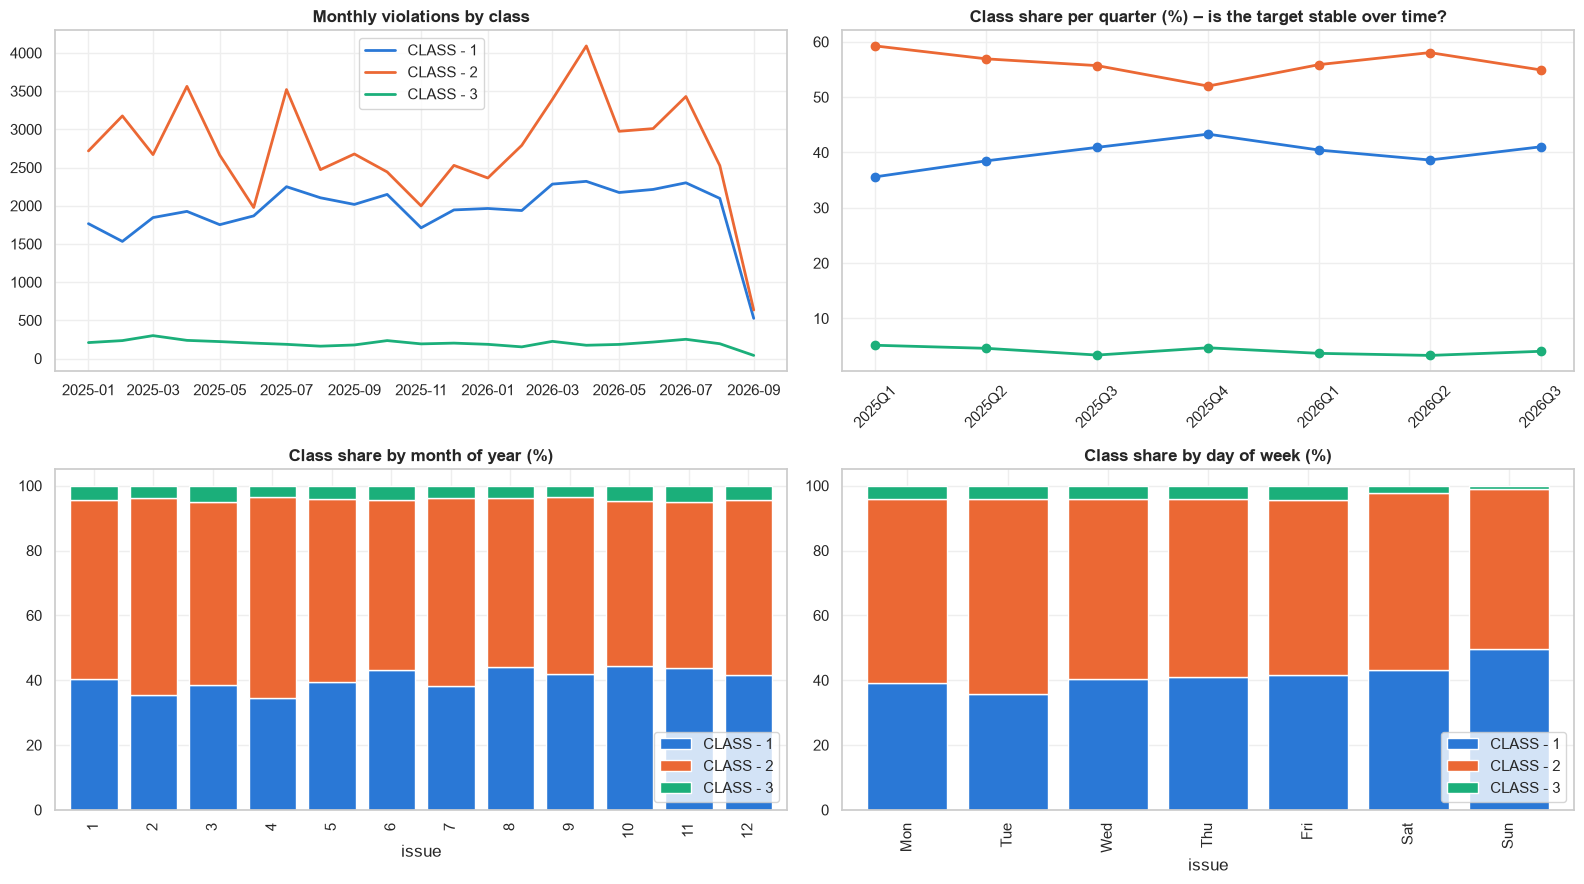

Volume by weekday: {'Mon': 18114, 'Tue': 22775, 'Wed': 20595, 'Thu': 20138, 'Fri': 16393, 'Sat': 3165, 'Sun': 1287}


In [65]:
dates = pd.DataFrame({'issue': d_issue, 'SEVERITY': df[TARGET]})
print('Issue date range:', dates.issue.min().date(), '→', dates.issue.max().date())
print('Records per year:', dates.issue.dt.year.value_counts().sort_index().to_dict())

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
m = dates.set_index('issue').groupby([pd.Grouper(freq='MS'), 'SEVERITY']).size().unstack()[CLASS_ORDER]
for c in CLASS_ORDER: axes[0,0].plot(m.index, m[c], color=CLASS_COLORS[c], lw=2, label=c)
axes[0,0].set_title('Monthly violations by class'); axes[0,0].legend()
q = pd.crosstab(dates.issue.dt.to_period('Q'), dates.SEVERITY, normalize='index')[CLASS_ORDER]
for c in CLASS_ORDER: axes[0,1].plot(q.index.astype(str), q[c]*100, color=CLASS_COLORS[c], lw=2, marker='o', label=c)
axes[0,1].set_title('Class share per quarter (%) – is the target stable over time?'); axes[0,1].tick_params(axis='x', rotation=45)
mo = pd.crosstab(dates.issue.dt.month, dates.SEVERITY, normalize='index')[CLASS_ORDER]*100
mo.plot(kind='bar', stacked=True, color=[CLASS_COLORS[c] for c in CLASS_ORDER], ax=axes[1,0], width=.8, edgecolor='white')
axes[1,0].set_title('Class share by month of year (%)'); axes[1,0].legend(loc='lower right')
dw = pd.crosstab(dates.issue.dt.day_name().str[:3], dates.SEVERITY)
dw = dw.reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
(dw.div(dw.sum(1), axis=0)[CLASS_ORDER]*100).plot(kind='bar', stacked=True, color=[CLASS_COLORS[c] for c in CLASS_ORDER],
                                                  ax=axes[1,1], width=.8, edgecolor='white')
axes[1,1].set_title('Class share by day of week (%)'); axes[1,1].legend(loc='lower right')
plt.tight_layout(); plt.show()
print('Volume by weekday:', dw.sum(1).to_dict())

**Findings & decisions – dates**
* Range **2024-01-01 → 2026-09-24**, ~52–58k violations per year (2026 partial).
* Class shares are **fairly stable per quarter** (Class 1 ≈ 34–49 %, Class 3 ≈ 4–6 %), with a mild upward drift in Class 1 → a **chronological (time-based) train/test split** is the realistic evaluation: the system will always predict *future* violations, and history features must only look backwards.
* **Weekend** violations are far more often Class 1 (Sat ≈ 45 %, Sun ≈ 52 % vs ≈ 39 % on weekdays) – weekend inspections are emergency/complaint responses. → engineer **`ISSUE_DAYOFWEEK` / `IS_WEEKEND`**.
* The **October-2024 spike** in Class 1 is a single administrative batch: **2,412 summonses on 2024-10-01**, ~2,150 of them the same *"failure to submit the required parking structure initial observation report"* (PIPS) template, 95 % Class 1. So the October/Q4 effect is largely a **campaign artefact**, not seasonality. → engineer **`ISSUE_MONTH`** (cheap, trees can use it) but don't over-interpret it; the template itself will be learned from the text. Bulk campaigns like this also mean the same text can dominate one period – another reason for a time-based split.
* **Year is NOT used as a feature:** only 3 values, and future years never appear in training → it would only encode drift.
* **HEARING_DATE and SERVED_DATE**: not used (post-event / weak) – see Sections 5 & 11.
* Issue date + BIN allow **historical features** (prior violations at the same building), computed strictly from earlier dates.

## 9. Outlier Investigation
**Purpose:** identify outliers with IQR, then decide per variable — *never auto-delete*.

In [66]:
def iqr_report(s):
    s = s.dropna(); q1, q3 = s.quantile([.25, .75]); iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    return pd.Series({'Q1': q1, 'Q3': q3, 'IQR': iqr, 'lower_fence': lo, 'upper_fence': hi,
                      'n_outliers': int(((s < lo) | (s > hi)).sum()),
                      'outlier_%': round(((s < lo) | (s > hi)).mean()*100, 2), 'max': s.max()})

# engineered-candidate numeric: prior violations at the same building (strictly earlier dates)
tmpb = pd.DataFrame({'BIN': df['BIN'].where(~df['BIN'].str.fullmatch(r'[1-5]000000', na=False)), 'd': d_issue})
per_day = tmpb.dropna().groupby(['BIN', 'd']).size().rename('n').reset_index().sort_values(['BIN', 'd'])
per_day['prior'] = per_day.groupby('BIN')['n'].cumsum() - per_day['n']
num['BIN_PRIOR_VIOLATIONS'] = tmpb.merge(per_day, on=['BIN', 'd'], how='left')['prior'].values
num['DESC_WORDS'] = tl['words']

out = num.apply(iqr_report).T.round(2)
out

,Q1,Q3,IQR,lower_fence,upper_fence,n_outliers,outlier_%,max
PENALITY_IMPOSED,1250.0,3125.0,1875.0,-1562.5,5937.5,18731.0,18.28,70000.0
AMOUNT_PAID,0.0,0.0,0.0,0.0,0.0,18810.0,18.36,57500.0
BALANCE_DUE,0.0,2530.0,2530.0,-3795.0,6325.0,9759.0,9.52,70000.0
SERVED_LAG_DAYS,0.0,0.0,0.0,0.0,0.0,21322.0,20.81,537.0
HEARING_GAP_DAYS,69.0,282.0,213.0,-250.5,601.5,2517.0,2.46,881.0
BIN_PRIOR_VIOLATIONS,0.0,2.0,2.0,-3.0,5.0,9573.0,9.36,60.0
DESC_WORDS,28.0,34.0,6.0,19.0,43.0,5227.0,5.10,49.0


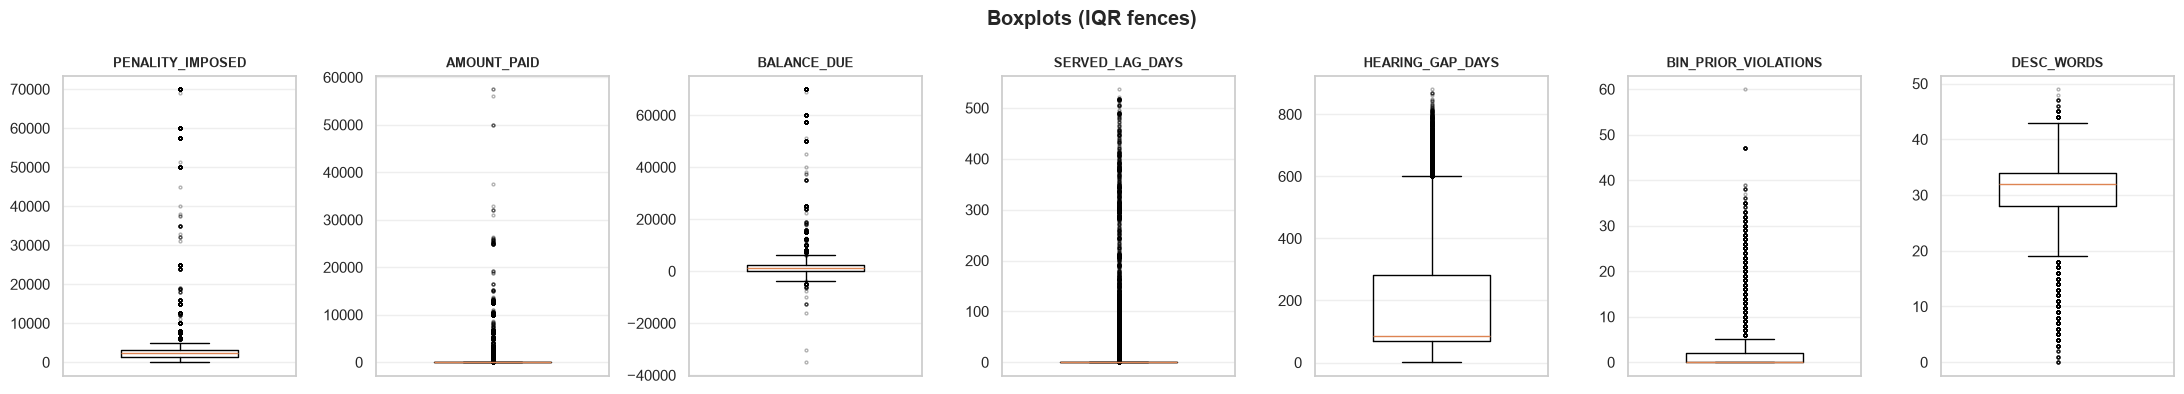

count    102291.00
mean          1.66
std           3.47
min           0.00
25%           0.00
50%           0.00
75%           2.00
max          60.00
Name: BIN_PRIOR_VIOLATIONS, dtype: float64
SEVERITY              CLASS - 1  CLASS - 2  CLASS - 3
BIN_PRIOR_VIOLATIONS                                 
(-1, 0]                   0.395      0.548      0.056
(0, 2]                    0.408      0.567      0.025
(2, 5]                    0.388      0.598      0.014
(5, 20]                   0.396      0.598      0.006
(20, 1000]                0.420      0.577      0.003


In [67]:
fig, axes = plt.subplots(1, len(num.columns), figsize=(22, 4))
for i, c in enumerate(num.columns):
    axes[i].boxplot(num[c].dropna(), vert=True, widths=.5, flierprops=dict(markersize=2, alpha=.3))
    axes[i].set_title(c, fontsize=9); axes[i].set_xticks([])
plt.suptitle('Boxplots (IQR fences)', fontweight='bold'); plt.tight_layout(); plt.show()
print(num['BIN_PRIOR_VIOLATIONS'].describe().round(2))
print(pd.crosstab(pd.cut(num['BIN_PRIOR_VIOLATIONS'], [-1, 0, 2, 5, 20, 1000]), df[TARGET], normalize='index').round(3))

**Findings & per-variable decisions**

| Variable | Outliers | Genuine or error? | Decision |
|---|---|---|---|
| PENALITY_IMPOSED / AMOUNT_PAID / BALANCE_DUE | 8–20 % beyond fences | Genuine (legal fines up to $70k, refunds) | **Irrelevant – columns removed as leakage.** Treating them would be wasted effort. |
| SERVED_LAG_DAYS | ~22 % (every non-zero lag, since IQR = 0) | Genuine (late service) | Column not used. |
| HEARING_GAP_DAYS | few | Genuine (adjournments) | Column removed (post-event). |
| BIN_PRIOR_VIOLATIONS (engineered) | ~9 % beyond fence (>7.5); max 84 | **Genuine** – large sites / public schools / NYCHA really have many violations, and *repeat offending is exactly the signal we want* | **Keep**, no capping. Apply **log1p** for linear & NB models; trees are split-based and unaffected. |
| DESC_WORDS | few short texts | Genuine (short descriptions) | **Keep**; bounded by the 210-char cap. |

Deleting "outliers" here would remove the high-risk buildings the system is meant to prioritise and would bias the minority classes.

## 10. Feature Relationship Analysis
**Purpose:** combine the evidence – which candidate (non-leaky) features actually carry signal?

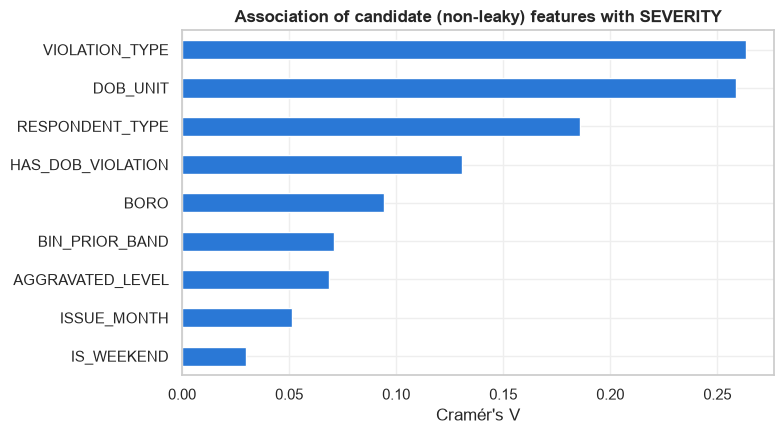

VIOLATION_TYPE       0.263
DOB_UNIT             0.258
RESPONDENT_TYPE      0.186
HAS_DOB_VIOLATION    0.131
BORO                 0.094
BIN_PRIOR_BAND       0.071
AGGRAVATED_LEVEL     0.068
ISSUE_MONTH          0.051
IS_WEEKEND           0.030
Name: Cramér's V, dtype: float64

In [68]:
# Candidate engineered features (computed here for EDA only; the final version is built in Notebook 2)
name = df['RESPONDENT_NAME'].fillna('').str.upper()
gov = name.str.contains(r'DEPARTMENT|DEPT|\bNYC\b|CITY OF|HOUSING AUTH|SCHOOL|BOARD OF ED|\bHPD\b|\bDOE\b|AUTHORITY|\bMTA\b|STATE OF')
org = name.str.contains(r'\bLLC\b|\bINC\b|CORP|\bCO\b|LTD|\bLP\b|ASSOC|REALTY|MGMT|MANAGEMENT|TRUST|CONDO|CONSTRUCT|DEVELOP|PROPERT|HOLDING|GROUP|BUILDERS|CONTRACT|SERVICES|ENTERPRISE|OWNER|CHURCH|HOSPITAL|UNIVERSITY|COOP|CO-OP|HDFC|L\.L\.C')
resp_type = np.select([name.eq(''), gov, org], ['UNKNOWN', 'GOVERNMENT', 'ORGANISATION'], 'INDIVIDUAL')
dob_unit = df['DOB_VIOLATION_NUMBER'].str.extract(r'^\d{8}([A-Z]+)')[0].str[:4].fillna('NONE')

cand = pd.DataFrame({
    'BORO': df['BORO'], 'VIOLATION_TYPE': df['VIOLATION_TYPE'], 'AGGRAVATED_LEVEL': df['AGGRAVATED_LEVEL'],
    'RESPONDENT_TYPE': resp_type, 'HAS_DOB_VIOLATION': df['DOB_VIOLATION_NUMBER'].notna().astype(int),
    'DOB_UNIT': dob_unit, 'IS_WEEKEND': (d_issue.dt.dayofweek >= 5).astype(int),
    'ISSUE_MONTH': d_issue.dt.month,
    'BIN_PRIOR_BAND': pd.cut(num['BIN_PRIOR_VIOLATIONS'].fillna(0), [-1, 0, 2, 5, 1e6], labels=['0', '1-2', '3-5', '6+']),
})
rel = pd.Series({c: cramers_v(cand[c].astype(str), df[TARGET]) for c in cand.columns}, name="Cramér's V").sort_values()
rel.plot(kind='barh', color=NEUTRAL, figsize=(8, 4.5), title="Association of candidate (non-leaky) features with SEVERITY")
plt.xlabel("Cramér's V"); plt.tight_layout(); plt.show()
rel.sort_values(ascending=False).round(3)

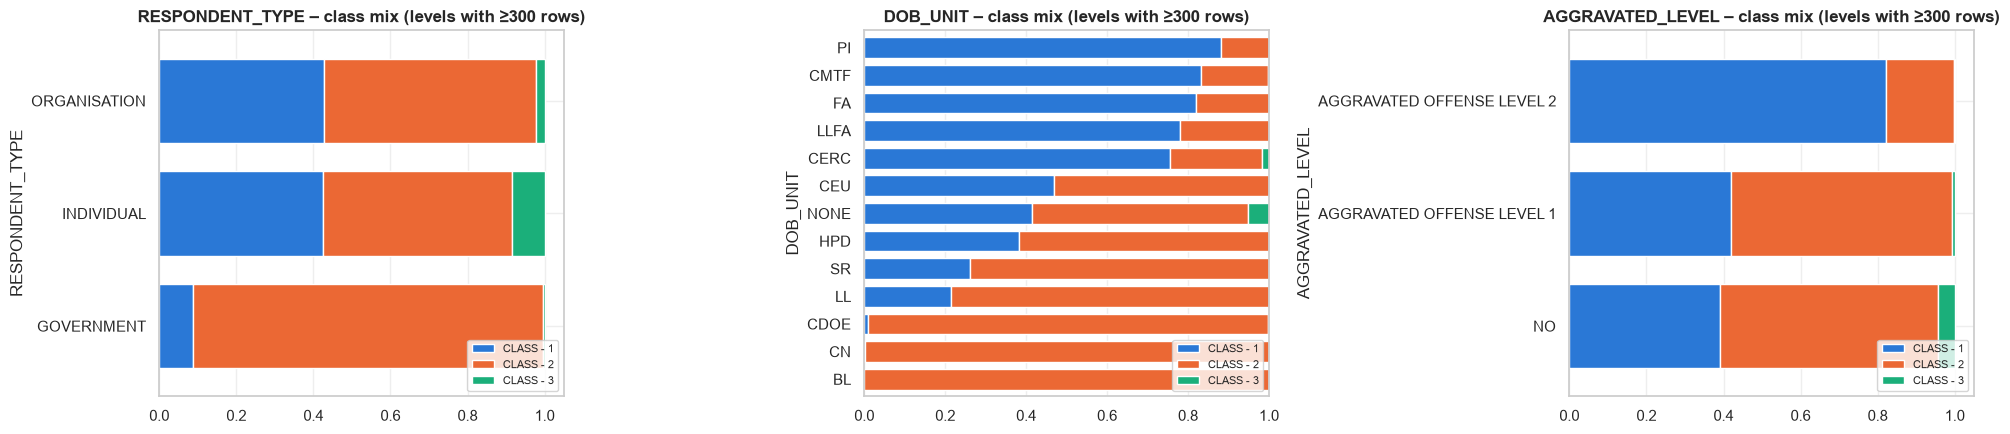

SEVERITY         CLASS - 1  CLASS - 2  CLASS - 3
RESPONDENT_TYPE                                 
GOVERNMENT           0.087      0.910      0.004
INDIVIDUAL           0.425      0.491      0.084
ORGANISATION         0.428      0.550      0.022
UNKNOWN              0.107      0.893      0.000


In [69]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4.5))
for ax, c in zip(axes, ['RESPONDENT_TYPE', 'DOB_UNIT', 'AGGRAVATED_LEVEL']):
    ct = pd.crosstab(cand[c], df[TARGET])
    ct = ct[ct.sum(1) >= 300]
    (ct.div(ct.sum(1), axis=0)[CLASS_ORDER]).sort_values('CLASS - 1').plot(kind='barh', stacked=True,
        color=[CLASS_COLORS[k] for k in CLASS_ORDER], ax=ax, width=.75, edgecolor='white')
    ax.set_title(f'{c} – class mix (levels with ≥300 rows)'); ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()
print(pd.crosstab(cand['RESPONDENT_TYPE'], df[TARGET], normalize='index').round(3))

                      BIN_PRIOR_VIOLATIONS  DESC_WORDS  DESC_CHARS  ISSUE_MONTH  IS_WEEKEND
BIN_PRIOR_VIOLATIONS                  1.00       -0.04        0.02         0.09        0.04
DESC_WORDS                           -0.04        1.00        0.61        -0.00        0.03
DESC_CHARS                            0.02        0.61        1.00        -0.03        0.03
ISSUE_MONTH                           0.09       -0.00       -0.03         1.00       -0.00
IS_WEEKEND                            0.04        0.03        0.03        -0.00        1.00


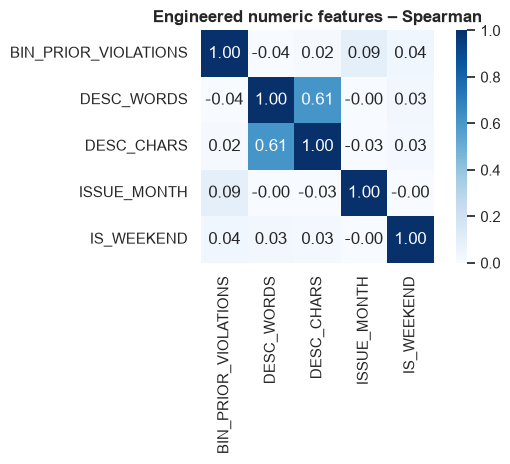

In [70]:
# Engineered numeric relationships (Spearman) – check redundancy
eng_num = pd.DataFrame({'BIN_PRIOR_VIOLATIONS': num['BIN_PRIOR_VIOLATIONS'].fillna(0),
                        'DESC_WORDS': num['DESC_WORDS'], 'DESC_CHARS': tl['chars'],
                        'ISSUE_MONTH': cand['ISSUE_MONTH'], 'IS_WEEKEND': cand['IS_WEEKEND']})
print(eng_num.corr('spearman').round(2))
sns.heatmap(eng_num.corr('spearman'), annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, square=True)
plt.title('Engineered numeric features – Spearman'); plt.tight_layout(); plt.show()

**Findings**
* Legitimate signal ranking: **VIOLATION_TYPE** and **DOB_UNIT** (issuing unit) are strongest, then **RESPONDENT_TYPE** (Government respondents → 91 % Class 2 "failure to file" type violations; Individuals → most Class 3, i.e. small homes/zoning), **HAS_DOB_VIOLATION**, **AGGRAVATED_LEVEL**, then weaker BORO, building history, weekend and month.
* `DESC_WORDS` and `DESC_CHARS` are moderately correlated (ρ ≈ 0.58) and both are dominated by the 210-char truncation with equal medians across classes → keep only **one** (word count) as a weak feature; engineered numerics are otherwise uncorrelated (|ρ| < 0.06) → no redundancy problem.
* Building history: more prior violations → **less Class 3** (6.2 % with no history vs 0.5 % with >20) and more Class 2 → useful, monotonic signal.
* No single structured feature is close to deterministic — performance will come from **combining text + context**, which is exactly what makes the ML problem meaningful (versus the leaky infraction code, next section).

## 11. Data Leakage Investigation (critical)
**Purpose:** prove, with evidence, which columns reveal the target directly (definition), indirectly (derived from it), or are only known after the event.
### 11a. Infraction code – the legal definition of the class

In [71]:
ic = df['INFRACTION_CODE1']
ct = pd.crosstab(ic, df[TARGET])
purity = ct.max(axis=1).sum() / ct.values.sum()
print(f'INFRACTION_CODE1: {ic.nunique()} codes; predicting the majority class of each code gives accuracy = {purity:.3f}')
print('\nFirst character of the code vs severity:')
print(pd.crosstab(ic.str[0], df[TARGET]))
print("\nCramér's V (INFRACTION_CODE1, SEVERITY) =", round(cramers_v(ic, df[TARGET]), 3))

INFRACTION_CODE1: 326 codes; predicting the majority class of each code gives accuracy = 0.987

First character of the code vs severity:
SEVERITY          CLASS - 1  CLASS - 2  CLASS - 3
INFRACTION_CODE1                                 
1                     39356          0          0
2                      1306      57563          0
3                        11         44       4186
Z                         0          0          1

Cramér's V (INFRACTION_CODE1, SEVERITY) = 0.982


In [72]:
# Demonstration: a trivial 1-feature model already "solves" the task -> proof of leakage
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score, f1_score

X_ic = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1).fit_transform(ic.to_frame())
Xtr, Xte, ytr, yte = train_test_split(X_ic, df[TARGET], test_size=.2, stratify=df[TARGET], random_state=42)
leak_tree = DecisionTreeClassifier(random_state=42).fit(Xtr, ytr)
p = leak_tree.predict(Xte)
print(f'Decision tree on INFRACTION_CODE1 ONLY -> accuracy {accuracy_score(yte, p):.3f}, macro-F1 {f1_score(yte, p, average="macro"):.3f}')

sld = df['SECTION_LAW_DESCRIPTION1'].fillna('')
print('\nSECTION_LAW_DESCRIPTION1 text explicitly containing "CLASS":', sld.str.contains('CLASS').mean().round(3))
print(sld[sld.str.contains('CLASS')].str.replace(r'\s+', ' ', regex=True).head(3).to_string())

Decision tree on INFRACTION_CODE1 ONLY -> accuracy 0.987, macro-F1 0.989

SECTION_LAW_DESCRIPTION1 text explicitly containing "CLASS": 0.0
4612    28-202.1 ADDITIONAL DAILY PENALTY FOR CLASS 1 VIOLATION OF 28-210.1 OR 28-210.2
5424                28-202.1 ADDITIONAL DAILY PENALTY FOR CLASS 1 VIOLATION OF 28-210.3
5489    28-202.1 ADDITIONAL DAILY PENALTY FOR CLASS 1 VIOLATION OF 28-210.1 OR 28-210.2


### 11b. Post-event columns (only exist after the hearing / payment)

In [73]:
print('PENALITY_IMPOSED median by class:\n', pd.Series(money['PENALITY_IMPOSED']).groupby(df[TARGET]).median(), '\n')
print("Cramér's V – post-event categorical columns:")
for c in ['HEARING_STATUS', 'CERTIFICATION_STATUS', 'ECB_VIOLATION_STATUS']:
    print(f'  {c:22s}', round(cramers_v(df[c].fillna('MISSING'), df[TARGET]), 3))
print('\nCERTIFICATION_STATUS = CURE ACCEPTED by class (cure is legally only possible for Class 2/3):')
print(pd.crosstab(df['CERTIFICATION_STATUS'].eq('CURE ACCEPTED'), df[TARGET]))
print('\nHEARING_STATUS = CURED/IN-VIO by class:')
print(pd.crosstab(df['HEARING_STATUS'].eq('CURED/IN-VIO'), df[TARGET]))

PENALITY_IMPOSED median by class:
 SEVERITY
CLASS - 1    2500.0
CLASS - 2    1250.0
CLASS - 3     280.0
Name: PENALITY_IMPOSED, dtype: float64 

Cramér's V – post-event categorical columns:
  HEARING_STATUS         0.261
  CERTIFICATION_STATUS   0.195
  ECB_VIOLATION_STATUS   0.017

CERTIFICATION_STATUS = CURE ACCEPTED by class (cure is legally only possible for Class 2/3):
SEVERITY              CLASS - 1  CLASS - 2  CLASS - 3
CERTIFICATION_STATUS                                 
False                     40673      51705       3414
True                          0       5902        773

HEARING_STATUS = CURED/IN-VIO by class:
SEVERITY        CLASS - 1  CLASS - 2  CLASS - 3
HEARING_STATUS                                 
False               40673      51705       3414
True                    0       5902        773


### 11c. Identifiers

In [74]:
print("ECB_VIOLATION_NUMBER prefix vs class (it encodes the issuing series, not the condition):")
print(pd.crosstab(df['ECB_VIOLATION_NUMBER'].str[:2], df[TARGET]))

ECB_VIOLATION_NUMBER prefix vs class (it encodes the issuing series, not the condition):


SEVERITY              CLASS - 1  CLASS - 2  CLASS - 3
ECB_VIOLATION_NUMBER                                 
35                         7242      10586         50
37                            1       3777          0
38                           14          5          0
39                        33416      43239       4137


### 11d. Leakage verdicts

| Feature | Evidence | Type of leakage | Verdict |
|---|---|---|---|
| INFRACTION_CODE1 | 1-feature tree ≈ 98 % accuracy; first char 1/2/3 ≈ class | **Direct** – the class is *looked up* from the code (1 RCNY §102-01) | **REMOVE** |
| INFRACTION_CODE2–10 | same coding scheme, mostly empty | Direct | **REMOVE** |
| SECTION_LAW_DESCRIPTION1–10 | 1-to-1 text version of the code; some say "CLASS 1 VIOLATION" | Direct (textual copy of code) | **REMOVE** |
| PENALITY_IMPOSED | median $2,500 / $1,250 / $250 by class | **Indirect** – penalty schedule is set by class; also assessed at/after hearing | **REMOVE** |
| AMOUNT_PAID, BALANCE_DUE | derived from penalty; exist only after payment | Post-event + indirect | **REMOVE** |
| HEARING_STATUS | 'CURED/IN-VIO' never Class 1 | Post-event (future information) | **REMOVE** |
| CERTIFICATION_STATUS | 'CURE ACCEPTED' never Class 1 | Post-event | **REMOVE** |
| ECB_VIOLATION_STATUS | ACTIVE/RESOLVE – current state | Post-event | **REMOVE** |
| HEARING_DATE (→ hearing gap) | differs by class, but reflects later adjournments | Post-event (updated) | **REMOVE** |
| HEARING_TIME | scheduling slot | Operational, no causal meaning | **REMOVE** |
| ISN_DOB_BIS_EXTRACT, ECB_VIOLATION_NUMBER | unique per row; prefix = issuance series | ID – memorisation / spurious | **REMOVE** |
| BIN, BLOCK, LOT | IDs; BIN 55k levels | ID – would memorise buildings | **REMOVE raw**, use BIN **only to compute past history** |
| DOB_VIOLATION_NUMBER | issued with the summons; contains date + issuing-unit code | Not leakage (known at issuance) | **KEEP derived** flag + unit code, drop raw string |
| AGGRAVATED_LEVEL | charged on the summons at issuance | Not leakage | **KEEP** |
| VIOLATION_DESCRIPTION | inspector's observation at issuance | Not leakage, but mask explicit class words | **KEEP (cleaned)** |
| Building history (BIN prior counts / prior Class-1 counts) | uses only violations with *earlier* issue dates | Safe *only* if computed backward-in-time | **KEEP (engineered carefully)** |
| RESPONDENT_* | PII; mailing address ≠ building | Ethical, not leakage | **REMOVE raw**; keep coarse respondent *type* only |

**Prevention strategy:** remove all leaky columns **before** splitting; engineer history strictly from past dates; split **chronologically**; fit every transformer (TF-IDF vocabulary, encoders, scalers, feature selectors) on the **training fold only**.

## 12. EDA Summary → Preprocessing Decisions

| # | EDA finding | Preprocessing / modelling decision |
|---|---|---|
| 1 | Target complete, 3 classes, 13 : 1 imbalance | Class weights; macro-F1 + Class-1 recall; stratification check on split |
| 2 | 18 empty columns; code 2-3 ≥ 96 % empty | Drop |
| 3 | Leakage: infraction codes, law text, money, hearing/cert/ECB status, hearing date | Drop before split |
| 4 | 209 duplicate re-entries | Drop duplicates (ignoring IDs) |
| 5 | Placeholder BINs | Set to NaN before history features |
| 6 | DOB number missingness is informative (MNAR) | `HAS_DOB_VIOLATION` + `DOB_UNIT` ('NONE' when missing) |
| 7 | Description = main signal, truncated, contains IDs/dates and a few class words | Clean + mask → TF-IDF (1-2 grams) |
| 8 | VIOLATION_TYPE, BORO nominal, few levels, some rare | One-Hot with `min_frequency` |
| 9 | AGGRAVATED_LEVEL ordinal | Ordinal 0/1/2 |
| 10 | Respondent name is PII but type is predictive | Derive `RESPONDENT_TYPE`, drop raw |
| 11 | Weekend ⇒ more Class 1; mild month effect; year = drift | `ISSUE_DAYOFWEEK`, `IS_WEEKEND`, `ISSUE_MONTH`; no year |
| 12 | Repeat buildings; counts right-skewed, genuine outliers | Backward-looking BIN history features; keep outliers; log1p |
| 13 | Class mix drifts slightly over time | **Chronological train/test split** |
| 14 | No raw numeric features left needing imputation | No mean/median imputation (proposal step not required) |

## Viva preparation — likely questions (EDA)

**Q: Why didn't you use INFRACTION_CODE1? It is the most predictive column.**
A: Because it *is* the answer. Under 1 RCNY §102-01 each infraction code is pre-assigned a class; a single-feature tree gets ~98 % accuracy. A model using it only reproduces a lookup table and can't help triage before a code is assigned.

**Q: Why is the penalty removed? It's a number, not the class.**
A: The penalty schedule is determined *by* the class, and the amount is imposed at the hearing — after the event we want to predict. It is an effect of the target (indirect leakage).

**Q: Why not impute missing values with mean/median as in your proposal?**
A: EDA showed every numeric column with gaps is a leakage column that is dropped. The remaining gaps are categorical/informative (DOB number) and are encoded as their own level. Imputation would add no value.

**Q: Why keep outliers?**
A: They are genuine — buildings with many prior violations are real high-risk sites, which is the signal. We log-transform for linear models instead of deleting information.

**Q: Why a time-based split instead of random?**
A: The deployed system predicts future violations; history features look backwards; and the class mix drifts slightly. A random split would let the model see "the future" of a building and give optimistic scores.

**Q: Why accuracy is not your main metric?**
A: With 56 % Class 2, a constant predictor gets 56 % accuracy and 0 recall on Class 3. Macro-F1 weights all three classes equally; Class-1 recall matters most for safety.